In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/rm1000/lung-cancer-histopathological-images/squamous_cell_carcinoma/0664.jpg
/kaggle/input/datasets/rm1000/lung-cancer-histopathological-images/squamous_cell_carcinoma/1269.jpg
/kaggle/input/datasets/rm1000/lung-cancer-histopathological-images/squamous_cell_carcinoma/3863.jpg
/kaggle/input/datasets/rm1000/lung-cancer-histopathological-images/squamous_cell_carcinoma/2193.jpg
/kaggle/input/datasets/rm1000/lung-cancer-histopathological-images/squamous_cell_carcinoma/0733.jpg
/kaggle/input/datasets/rm1000/lung-cancer-histopathological-images/squamous_cell_carcinoma/3750.jpg
/kaggle/input/datasets/rm1000/lung-cancer-histopathological-images/squamous_cell_carcinoma/2008.jpg
/kaggle/input/datasets/rm1000/lung-cancer-histopathological-images/squamous_cell_carcinoma/2081.jpg
/kaggle/input/datasets/rm1000/lung-cancer-histopathological-images/squamous_cell_carcinoma/0106.jpg
/kaggle/input/datasets/rm1000/lung-cancer-histopathological-images/squamous_cell_carcinoma/0375.jpg


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("abdullahhasansajjad/lunghist700")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/abdullahhasansajjad/lunghist700


In [5]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rm1000/lung-cancer-histopathological-images")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/rm1000/lung-cancer-histopathological-images


In [4]:
import os

for root, dirs, files in os.walk("/kaggle/input/datasets/rm1000/lung-cancer-histopathological-images"):
    print(root)
    if len(files):
        print(files[:3])

/kaggle/input/datasets/rm1000/lung-cancer-histopathological-images
/kaggle/input/datasets/rm1000/lung-cancer-histopathological-images/squamous_cell_carcinoma
['0664.jpg', '1269.jpg', '3863.jpg']
/kaggle/input/datasets/rm1000/lung-cancer-histopathological-images/benign
['0664.jpg', '1269.jpg', '3863.jpg']
/kaggle/input/datasets/rm1000/lung-cancer-histopathological-images/adenocarcinoma
['0664.jpg', '1269.jpg', '3863.jpg']


In [5]:
import os

for root, dirs, files in os.walk("/kaggle/input/datasets/abdullahhasansajjad/lunghist700"):
    print(root)
    if len(files):
        print(files[:3])

/kaggle/input/datasets/abdullahhasansajjad/lunghist700
/kaggle/input/datasets/abdullahhasansajjad/lunghist700/LungHist700_combined
/kaggle/input/datasets/abdullahhasansajjad/lunghist700/LungHist700_combined/data
['data.csv']
/kaggle/input/datasets/abdullahhasansajjad/lunghist700/LungHist700_combined/data/images
/kaggle/input/datasets/abdullahhasansajjad/lunghist700/LungHist700_combined/data/images/aca
['aca_md_20x_304.jpg', 'aca_bd_40x_301.jpg', 'aca_bd_40x_17.jpg']
/kaggle/input/datasets/abdullahhasansajjad/lunghist700/LungHist700_combined/data/images/ssc
['scc_bd_40x_304.jpg', 'scc_bd_20x_903.jpg', 'scc_pd_40x_403.jpg']
/kaggle/input/datasets/abdullahhasansajjad/lunghist700/LungHist700_combined/data/images/nor
['nor_40x_404.jpg', 'nor_20x_63.jpg', 'nor_40x_28.jpg']


In [5]:
import os
import copy
import random
import warnings
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    matthews_corrcoef,
    cohen_kappa_score,
    roc_curve,
    auc
)

from sklearn.preprocessing import label_binarize

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [4]:
SEEDS = [42, 123, 999, 2025, 777]

def set_seed(seed):

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [5]:
LC25000_PATH = "/kaggle/input/datasets/rm1000/lung-cancer-histopathological-images"

LUNGHIST700_PATH = "/kaggle/input/datasets/abdullahhasansajjad/lunghist700"

In [7]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [9]:
from torchvision.datasets import ImageFolder
from torch.utils.data import random_split

# ---------------------------------
# LC25000 Dataset
# ---------------------------------

lc_dataset = ImageFolder(
    root=LC25000_PATH,
    transform=train_transform
)

print("Classes :", lc_dataset.classes)
print("Class mapping :", lc_dataset.class_to_idx)
print("Total Images :", len(lc_dataset))

Classes : ['adenocarcinoma', 'benign', 'squamous_cell_carcinoma']
Class mapping : {'adenocarcinoma': 0, 'benign': 1, 'squamous_cell_carcinoma': 2}
Total Images : 15000


In [10]:
train_size = int(0.70 * len(lc_dataset))
val_size = int(0.15 * len(lc_dataset))
test_size = len(lc_dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    lc_dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

# validation/test should not use augmentation
val_dataset.dataset.transform = test_transform
test_dataset.dataset.transform = test_transform

print(len(train_dataset))
print(len(val_dataset))
print(len(test_dataset))

10500
2250
2250


In [9]:
SEEDS = [42, 123, 999, 2025, 777]

for seed in SEEDS:
    print(f"\nRunning with seed {seed}")

    set_seed(seed)

    train_dataset, val_dataset, test_dataset = random_split(
        lc_dataset,
        [train_size, val_size, test_size],
        generator=torch.Generator().manual_seed(seed)
    )

    val_dataset.dataset.transform = test_transform
    test_dataset.dataset.transform = test_transform

    # Create dataloaders
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

    # Train model here


Running with seed 42

Running with seed 123

Running with seed 999

Running with seed 2025

Running with seed 777


In [10]:
lunghist_dataset = ImageFolder(
    root="/kaggle/input/datasets/abdullahhasansajjad/lunghist700/LungHist700_combined/data/images",
    transform=test_transform
)

print(lunghist_dataset.classes)
print(lunghist_dataset.class_to_idx)
print("Total Images :", len(lunghist_dataset))

['aca', 'nor', 'ssc']
{'aca': 0, 'nor': 1, 'ssc': 2}
Total Images : 691


In [11]:
from torch.utils.data import Dataset

class LungHist700Dataset(Dataset):

    def __init__(self, dataset):

        self.dataset = dataset

        self.mapping = {
            dataset.class_to_idx['aca']:0,
            dataset.class_to_idx['nor']:1,
            dataset.class_to_idx['ssc']:2
        }

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):

        image,label = self.dataset[idx]

        label = self.mapping[label]

        return image,label


lunghist_dataset = LungHist700Dataset(lunghist_dataset)

In [12]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

lunghist_loader = DataLoader(
    lunghist_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [11]:
from sklearn.utils.class_weight import compute_class_weight

targets = [label for _, label in train_dataset]

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(targets),
    y=targets
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float
).to(device)

print(class_weights)

tensor([0.9989, 0.9870, 1.0145], device='cuda:0')


In [14]:
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights

weights = ConvNeXt_Tiny_Weights.DEFAULT

model = convnext_tiny(weights=weights)

num_features = model.classifier[2].in_features

model.classifier[2] = nn.Linear(
    num_features,
    3
)

model = model.to(device)

print(model)

Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 196MB/s]  


ConvNeXt(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
      (1): LayerNorm2d((96,), eps=1e-06, elementwise_affine=True)
    )
    (1): Sequential(
      (0): CNBlock(
        (block): Sequential(
          (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (1): Permute()
          (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
          (3): Linear(in_features=96, out_features=384, bias=True)
          (4): GELU(approximate='none')
          (5): Linear(in_features=384, out_features=96, bias=True)
          (6): Permute()
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
      )
      (1): CNBlock(
        (block): Sequential(
          (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (1): Permute()
          (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
          (3): Linear(in_features=

In [15]:
criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler = CosineAnnealingLR(
    optimizer,
    T_max=20
)

scaler = torch.cuda.amp.GradScaler()

In [16]:
class EarlyStopping:

    def __init__(self, patience=7):

        self.patience = patience

        self.counter = 0

        self.best_loss = np.inf

        self.stop = False

    def __call__(self, val_loss):

        if val_loss < self.best_loss:

            self.best_loss = val_loss

            self.counter = 0

        else:

            self.counter += 1

            if self.counter >= self.patience:

                self.stop = True


early_stop = EarlyStopping(patience=7)

In [17]:
def train_one_epoch(model, loader):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    loop = tqdm(loader)

    use_amp = device.type == "cuda"

    for images, labels in loop:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(
            device_type=device.type,
            enabled=use_amp
        ):
            outputs = model(images)
            loss = criterion(outputs, labels)

        if use_amp:
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()

        running_loss += loss.item()

        preds = outputs.argmax(dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

        loop.set_postfix(
            loss=f"{loss.item():.4f}",
            acc=f"{100 * correct / total:.2f}%"
        )

    epoch_loss = running_loss / len(loader)
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [18]:
def validate(model, loader):

    model.eval()

    running_loss = 0

    correct = 0

    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)

            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, preds = torch.max(outputs,1)

            correct += (preds==labels).sum().item()

            total += labels.size(0)

    epoch_loss = running_loss/len(loader)

    epoch_acc = correct/total

    return epoch_loss, epoch_acc

In [21]:
NUM_EPOCHS = 10

best_acc = 0

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

for epoch in range(NUM_EPOCHS):

    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader
    )

    val_loss, val_acc = validate(
        model,
        val_loader
    )

    scheduler.step()

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)

    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Train Loss : {train_loss:.4f}")
    print(f"Train Acc  : {train_acc*100:.2f}%")

    print(f"Val Loss   : {val_loss:.4f}")
    print(f"Val Acc    : {val_acc*100:.2f}%")

    if val_acc > best_acc:

        best_acc = val_acc

        torch.save(
            model.state_dict(),
            "best_convnext_tiny.pth"
        )

        print("Model Saved.")

    early_stop(val_loss)

    if early_stop.stop:

        print("Early stopping...")

        break

print("\nTraining Finished.")


Epoch 1/10


  0%|          | 0/329 [00:00<?, ?it/s]

Train Loss : 0.0908
Train Acc  : 96.88%
Val Loss   : 0.0934
Val Acc    : 95.11%
Model Saved.

Epoch 2/10


  0%|          | 0/329 [00:00<?, ?it/s]

Train Loss : 0.0200
Train Acc  : 99.32%
Val Loss   : 0.0185
Val Acc    : 99.33%
Model Saved.

Epoch 3/10


...

Train Loss : 0.0018
Train Acc  : 99.94%
Val Loss   : 0.0005
Val Acc    : 100.00%
Model Saved.

Epoch 9/10


  0%|          | 0/329 [00:00<?, ?it/s]

Train Loss : 0.0014
Train Acc  : 99.95%
Val Loss   : 0.0030
Val Acc    : 99.91%

Epoch 10/10


  0%|          | 0/329 [00:00<?, ?it/s]

Train Loss : 0.0004
Train Acc  : 99.99%
Val Loss   : 0.0001
Val Acc    : 100.00%

Training Finished.


In [19]:
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights

NUM_EPOCHS = 10
SEEDS = [42, 123, 999, 2025, 777]

all_best_acc = []

for seed in SEEDS:

    print("\n" + "="*60)
    print(f"Training with Seed = {seed}")
    print("="*60)

    # -------------------------
    # Set seed
    # -------------------------
    set_seed(seed)

    # -------------------------
    # Dataset split
    # -------------------------
    train_dataset, val_dataset, test_dataset = random_split(
        lc_dataset,
        [train_size, val_size, test_size],
        generator=torch.Generator().manual_seed(seed)
    )

    val_dataset.dataset.transform = test_transform
    test_dataset.dataset.transform = test_transform

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False
    )

    # -------------------------
    # Model
    # -------------------------
    weights = ConvNeXt_Tiny_Weights.DEFAULT

    model = convnext_tiny(weights=weights)

    num_features = model.classifier[2].in_features

    model.classifier[2] = nn.Linear(
        num_features,
        3
    )

    model = model.to(device)

    # -------------------------
    # Optimizer
    # -------------------------
    optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

    # -------------------------
    # Scheduler
    # -------------------------
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=NUM_EPOCHS
    )

    # -------------------------
    # Early stopping
    # -------------------------
    early_stop = EarlyStopping(patience=5)

    # -------------------------
    # Reset variables
    # -------------------------
    best_acc = 0

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    # -------------------------
    # Training
    # -------------------------
    for epoch in range(NUM_EPOCHS):

        print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")

        train_loss, train_acc = train_one_epoch(
            model,
            train_loader
        )

        val_loss, val_acc = validate(
            model,
            val_loader
        )

        scheduler.step()

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)

        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(f"Train Loss : {train_loss:.4f}")
        print(f"Train Acc  : {train_acc*100:.2f}%")

        print(f"Val Loss   : {val_loss:.4f}")
        print(f"Val Acc    : {val_acc*100:.2f}%")

        if val_acc > best_acc:

            best_acc = val_acc

            torch.save(
                model.state_dict(),
                f"best_convnext_tiny_seed_{seed}.pth"
            )

            print("Model Saved.")

        early_stop(val_loss)

        if early_stop.stop:

            print("Early stopping...")
            break

    print(f"\nBest Validation Accuracy (Seed {seed}) = {best_acc*100:.2f}%")

    all_best_acc.append(best_acc)

print("\n" + "="*60)
print("Training Finished")
print("="*60)

print("Validation Accuracies:")
for seed, acc in zip(SEEDS, all_best_acc):
    print(f"Seed {seed}: {acc*100:.2f}%")

print(f"\nMean Validation Accuracy = {np.mean(all_best_acc)*100:.2f}%")
print(f"Std  Validation Accuracy = {np.std(all_best_acc)*100:.2f}%")


Training with Seed = 42

Epoch 1/10


  0%|          | 0/329 [00:00<?, ?it/s]

Train Loss : 0.0874
Train Acc  : 96.84%
Val Loss   : 0.0221
Val Acc    : 98.89%
Model Saved.

Epoch 2/10


  0%|          | 0/329 [00:00<?, ?it/s]

Train Loss : 0.0162
Train Acc  : 99.43%
Val Loss   : 0.2888
Val Acc    : 92.18%

Epoch 3/10


...

Train Loss : 0.0001
Train Acc  : 100.00%
Val Loss   : 0.0023
Val Acc    : 99.91%

Epoch 9/10


  0%|          | 0/329 [00:00<?, ?it/s]

Train Loss : 0.0001
Train Acc  : 100.00%
Val Loss   : 0.0028
Val Acc    : 99.91%

Epoch 10/10


  0%|          | 0/329 [00:00<?, ?it/s]

Train Loss : 0.0002
Train Acc  : 100.00%
Val Loss   : 0.0022
Val Acc    : 99.91%

Best Validation Accuracy (Seed 777) = 99.91%

Training Finished
Validation Accuracies:
Seed 42: 100.00%
Seed 123: 100.00%
Seed 999: 99.96%
Seed 2025: 100.00%
Seed 777: 99.91%

Mean Validation Accuracy = 99.97%
Std  Validation Accuracy = 0.04%


In [55]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("abdullahhasansajjad/lunghist700")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/abdullahhasansajjad/lunghist700


In [56]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rm1000/lung-cancer-histopathological-images")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/rm1000/lung-cancer-histopathological-images


In [57]:
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

LUNGHIST700_PATH = "/kaggle/input/datasets/abdullahhasansajjad/lunghist700/LungHist700_combined/data/images"

external_dataset = ImageFolder(
    root=LUNGHIST700_PATH,
    transform=test_transform
)

print(external_dataset.class_to_idx)
print("Images:", len(external_dataset))

external_loader = DataLoader(
    external_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

{'aca': 0, 'nor': 1, 'ssc': 2}
Images: 691


In [71]:
from sklearn.metrics import classification_report

In [73]:
import numpy as np
import torch

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    cohen_kappa_score,
    confusion_matrix
)

def evaluate(model, loader):

    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)

            outputs = model(images)

            preds = torch.argmax(outputs, dim=1)

            y_true.extend(labels.numpy().tolist())
            y_pred.extend(preds.cpu().numpy().tolist())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # ---------------- Debug ----------------
    print("="*60)
    print("True label distribution")
    print(np.unique(y_true, return_counts=True))

    print("\nPredicted label distribution")
    print(np.unique(y_pred, return_counts=True))

    print("\nConfusion Matrix")
    cm = confusion_matrix(y_true, y_pred)
    print(cm)
    print("="*60)

    # ---------------- Metrics ----------------
    acc = accuracy_score(y_true, y_pred)

    bal_acc = balanced_accuracy_score(
        y_true,
        y_pred
    )

    precision = precision_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    mcc = matthews_corrcoef(
        y_true,
        y_pred
    )

    kappa = cohen_kappa_score(
        y_true,
        y_pred
    )

    return (
        acc,
        bal_acc,
        precision,
        recall,
        f1,
        mcc,
        kappa,
        cm
    )
    

In [74]:
import numpy as np
import torch

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    cohen_kappa_score,
    confusion_matrix,
    classification_report
)

def evaluate(model, loader):

    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)

            outputs = model(images)

            preds = torch.argmax(outputs, dim=1)

            y_true.extend(labels.numpy().tolist())
            y_pred.extend(preds.cpu().numpy().tolist())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # ---------------- Debug ----------------
    print("="*60)
    print("True label distribution")
    print(np.unique(y_true, return_counts=True))

    print("\nPredicted label distribution")
    print(np.unique(y_pred, return_counts=True))

    print("\nConfusion Matrix")
    cm = confusion_matrix(y_true, y_pred)
    print(cm)

    # ---------------- Overall Metrics ----------------
    acc = accuracy_score(y_true, y_pred)

    bal_acc = balanced_accuracy_score(
        y_true,
        y_pred
    )

    precision = precision_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    mcc = matthews_corrcoef(
        y_true,
        y_pred
    )

    kappa = cohen_kappa_score(
        y_true,
        y_pred
    )

    # ---------------- Per-Class Metrics ----------------
    class_names = ["ACA", "Normal", "SSC"]

    report = classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        output_dict=True,
        zero_division=0
    )

    print("\nPer-Class Metrics")
    print("-"*60)

    for cls in class_names:

        print(f"\n{cls}")
        print(f"Precision : {report[cls]['precision']:.4f}")
        print(f"Recall    : {report[cls]['recall']:.4f}")
        print(f"F1-score  : {report[cls]['f1-score']:.4f}")
        print(f"Support   : {int(report[cls]['support'])}")

    print("="*60)

    return (
        acc,
        bal_acc,
        precision,
        recall,
        f1,
        mcc,
        kappa,
        cm,
        report
    )

In [76]:
import pandas as pd

SEEDS = [42,123,999,2025,777]

results = []

for seed in SEEDS:

    print("="*70)
    print(f"Evaluating Seed {seed}")
    print("="*70)

    weights = ConvNeXt_Tiny_Weights.DEFAULT

    model = convnext_tiny(weights=weights)

    num_features = model.classifier[2].in_features
    model.classifier[2] = nn.Linear(num_features,3)

    model.load_state_dict(
        torch.load(
            f"best_convnext_tiny_seed_{seed}.pth",
            map_location=device
        )
    )

    model = model.to(device)
    model.eval()

    acc, bal_acc, prec, rec, f1, mcc, kappa, cm,report = evaluate(
        model,
        external_loader
    )

    print(f"Accuracy           : {acc*100:.2f}%")
    print(f"Balanced Accuracy  : {bal_acc*100:.2f}%")
    print(f"Precision          : {prec*100:.2f}%")
    print(f"Recall             : {rec*100:.2f}%")
    print(f"F1-score           : {f1*100:.2f}%")
    print(f"MCC                : {mcc:.4f}")
    print(f"Kappa              : {kappa:.4f}")

    results.append({
        "Seed": seed,
        "Accuracy": acc*100,
        "Balanced Accuracy": bal_acc*100,
        "Precision": prec*100,
        "Recall": rec*100,
        "F1-score": f1*100,
        "MCC": mcc,
        "Kappa": kappa
    })

Evaluating Seed 42
True label distribution
(array([0, 1, 2]), array([280, 151, 260]))

Predicted label distribution
(array([0, 1, 2]), array([117,  32, 542]))

Confusion Matrix
[[ 82   2 196]
 [ 27  30  94]
 [  8   0 252]]

Per-Class Metrics
------------------------------------------------------------

ACA
Precision : 0.7009
Recall    : 0.2929
F1-score  : 0.4131
Support   : 280

Normal
Precision : 0.9375
Recall    : 0.1987
F1-score  : 0.3279
Support   : 151

SSC
Precision : 0.4649
Recall    : 0.9692
F1-score  : 0.6284
Support   : 260
Accuracy           : 52.68%
Balanced Accuracy  : 48.69%
Precision          : 66.38%
Recall             : 52.68%
F1-score           : 47.55%
MCC                : 0.3197
Kappa              : 0.2442
Evaluating Seed 123
True label distribution
(array([0, 1, 2]), array([280, 151, 260]))

Predicted label distribution
(array([0, 1, 2]), array([196,  23, 472]))

Confusion Matrix
[[112   1 167]
 [ 57  22  72]
 [ 27   0 233]]

Per-Class Metrics
---------------------

In [83]:
import pandas as pd

SEEDS = [42, 123, 999, 2025, 777]

results = []
per_class_results = []

for seed in SEEDS:

    print("="*70)
    print(f"Evaluating Seed {seed}")
    print("="*70)

    weights = ConvNeXt_Tiny_Weights.DEFAULT

    model = convnext_tiny(weights=weights)

    num_features = model.classifier[2].in_features
    model.classifier[2] = nn.Linear(num_features, 3)

    model.load_state_dict(
        torch.load(
            f"best_convnext_tiny_seed_{seed}.pth",
            map_location=device
        )
    )

    model = model.to(device)
    model.eval()

    acc, bal_acc, prec, rec, f1, mcc, kappa, cm, report = evaluate(
        model,
        external_loader
    )

    print(f"Accuracy           : {acc*100:.2f}%")
    print(f"Balanced Accuracy  : {bal_acc*100:.2f}%")
    print(f"Precision          : {prec*100:.2f}%")
    print(f"Recall             : {rec*100:.2f}%")
    print(f"F1-score           : {f1*100:.2f}%")
    print(f"MCC                : {mcc:.4f}")
    print(f"Kappa              : {kappa:.4f}")

    # Overall metrics
    results.append({
        "Seed": seed,
        "Accuracy": acc * 100,
        "Balanced Accuracy": bal_acc * 100,
        "Precision": prec * 100,
        "Recall": rec * 100,
        "F1-score": f1 * 100,
        "MCC": mcc,
        "Kappa": kappa
    })

    # Per-class metrics
    for cls in ["ACA", "Normal", "SSC"]:

        per_class_results.append({
            "Seed": seed,
            "Class": cls,
            "Precision": report[cls]["precision"] * 100,
            "Recall": report[cls]["recall"] * 100,
            "F1-score": report[cls]["f1-score"] * 100,
            "Support": int(report[cls]["support"])
        })

Evaluating Seed 42
True label distribution
(array([0, 1, 2]), array([280, 151, 260]))

Predicted label distribution
(array([0, 1, 2]), array([117,  32, 542]))

Confusion Matrix
[[ 82   2 196]
 [ 27  30  94]
 [  8   0 252]]

Per-Class Metrics
------------------------------------------------------------

ACA
Precision : 0.7009
Recall    : 0.2929
F1-score  : 0.4131
Support   : 280

Normal
Precision : 0.9375
Recall    : 0.1987
F1-score  : 0.3279
Support   : 151

SSC
Precision : 0.4649
Recall    : 0.9692
F1-score  : 0.6284
Support   : 260
Accuracy           : 52.68%
Balanced Accuracy  : 48.69%
Precision          : 66.38%
Recall             : 52.68%
F1-score           : 47.55%
MCC                : 0.3197
Kappa              : 0.2442
Evaluating Seed 123
True label distribution
(array([0, 1, 2]), array([280, 151, 260]))

Predicted label distribution
(array([0, 1, 2]), array([196,  23, 472]))

Confusion Matrix
[[112   1 167]
 [ 57  22  72]
 [ 27   0 233]]

Per-Class Metrics
---------------------

In [84]:
import pandas as pd

# ==========================================================
# OVERALL RESULTS
# ==========================================================

results_df = pd.DataFrame(results)

print("\n==================== PER-SEED RESULTS ====================\n")
print(results_df.round(2))

metrics = [
    "Accuracy",
    "Balanced Accuracy",
    "Precision",
    "Recall",
    "F1-score",
    "MCC",
    "Kappa"
]

summary = pd.DataFrame({
    "Metric": metrics,
    "Mean": [results_df[m].mean() for m in metrics],
    "SD": [results_df[m].std(ddof=1) for m in metrics]
})

summary["Mean ± SD"] = summary.apply(
    lambda x: f"{x['Mean']:.2f} ± {x['SD']:.2f}",
    axis=1
)

print("\n==================== OVERALL MEAN ± SD ====================\n")
print(summary[["Metric", "Mean ± SD"]])

# Save overall results
results_df.to_csv("LungHist700_5Seed_Results.csv", index=False)
summary.to_csv("LungHist700_Mean_SD.csv", index=False)


# ==========================================================
# PER-CLASS RESULTS
# ==========================================================

if len(per_class_results) > 0:

    per_class_df = pd.DataFrame(per_class_results)

    print("\n==================== PER-CLASS RESULTS ====================\n")
    print(per_class_df.round(2))

    rows = []

    for cls in ["ACA", "Normal", "SSC"]:

        temp = per_class_df[per_class_df["Class"] == cls]

        rows.append({
            "Class": cls,
            "Precision": f"{temp['Precision'].mean():.2f} ± {temp['Precision'].std(ddof=1):.2f}",
            "Recall": f"{temp['Recall'].mean():.2f} ± {temp['Recall'].std(ddof=1):.2f}",
            "F1-score": f"{temp['F1-score'].mean():.2f} ± {temp['F1-score'].std(ddof=1):.2f}",
        })

    per_class_summary = pd.DataFrame(rows)

    print("\n==================== PER-CLASS MEAN ± SD ====================\n")
    print(per_class_summary)

    per_class_df.to_csv("Per_Class_Results.csv", index=False)
    per_class_summary.to_csv("Per_Class_Mean_SD.csv", index=False)

else:
    print("\nper_class_results is empty.")
    print("You need to populate it inside the evaluation loop.")


==================== PER-SEED RESULTS ====================

   Seed  Accuracy  Balanced Accuracy  Precision  Recall  F1-score   MCC  Kappa
0    42     52.68              48.69      66.38   52.68     47.55  0.32   0.24
1   123     53.11              48.06      62.63   53.11     48.55  0.28   0.24
2   999     51.37              45.74      61.68   51.37     46.17  0.24   0.21
3  2025     50.36              45.07      61.84   50.36     44.03  0.24   0.20
4   777     52.53              47.58      60.12   52.53     47.92  0.27   0.24

==================== OVERALL MEAN ± SD ====================

              Metric     Mean ± SD
0           Accuracy  52.01 ± 1.12
1  Balanced Accuracy  47.03 ± 1.55
2          Precision  62.53 ± 2.34
3             Recall  52.01 ± 1.12
4           F1-score  46.84 ± 1.80
5                MCC   0.27 ± 0.03
6              Kappa   0.23 ± 0.02

==================== PER-CLASS RESULTS ====================

    Seed   Class  Precision  Recall  F1-score  Support
0     

In [81]:
import pandas as pd

results_df = pd.DataFrame(results)

print("\n==================== PER-SEED RESULTS ====================\n")
print(results_df.round(2))

metrics = [
    "Accuracy",
    "Balanced Accuracy",
    "Precision",
    "Recall",
    "F1-score",
    "MCC",
    "Kappa"
]

summary = pd.DataFrame({
    "Metric": metrics,
    "Mean": [results_df[m].mean() for m in metrics],
    "SD": [results_df[m].std(ddof=1) for m in metrics]
})

summary["Mean ± SD"] = summary.apply(
    lambda x: f"{x['Mean']:.2f} ± {x['SD']:.2f}",
    axis=1
)

print("\n==================== MEAN ± SD ====================\n")
print(summary)

# Optional: Save to CSV
results_df.to_csv("LungHist700_5Seed_Results.csv", index=False)
summary.to_csv("LungHist700_Mean_SD.csv", index=False)



==================== PER-SEED RESULTS ====================

   Seed  Accuracy  Balanced Accuracy  Precision  Recall  F1-score   MCC  Kappa
0    42     52.68              48.69      66.38   52.68     47.55  0.32   0.24
1   123     53.11              48.06      62.63   53.11     48.55  0.28   0.24
2   999     51.37              45.74      61.68   51.37     46.17  0.24   0.21
3  2025     50.36              45.07      61.84   50.36     44.03  0.24   0.20
4   777     52.53              47.58      60.12   52.53     47.92  0.27   0.24

==================== MEAN ± SD ====================

              Metric       Mean        SD     Mean ± SD
0           Accuracy  52.011577  1.123778  52.01 ± 1.12
1  Balanced Accuracy  47.027121  1.552775  47.03 ± 1.55
2          Precision  62.528320  2.337984  62.53 ± 2.34
3             Recall  52.011577  1.123778  52.01 ± 1.12
4           F1-score  46.842303  1.799648  46.84 ± 1.80
5                MCC   0.270475  0.032499   0.27 ± 0.03
6              Kapp

In [65]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

In [66]:
def plot_multiclass_roc(model, loader, class_names, seed):

    model.eval()

    y_true = []
    y_score = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)

            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)

            y_true.extend(labels.numpy())
            y_score.extend(probs.cpu().numpy())

    y_true = np.array(y_true)
    y_score = np.array(y_score)

    y_true_bin = label_binarize(
        y_true,
        classes=np.arange(len(class_names))
    )

    plt.figure(figsize=(7,6))

    auc_scores = {}

    for i in range(len(class_names)):

        fpr, tpr, _ = roc_curve(
            y_true_bin[:, i],
            y_score[:, i]
        )

        roc_auc = auc(fpr, tpr)

        auc_scores[class_names[i]] = roc_auc

        plt.plot(
            fpr,
            tpr,
            lw=2,
            label=f"{class_names[i]} (AUC = {roc_auc:.3f})"
        )

    # Macro AUC
    macro_auc = np.mean(list(auc_scores.values()))

    plt.plot([0,1],[0,1],'k--')

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - Seed {seed}\nMacro AUC = {macro_auc:.3f}")

    plt.legend(loc="lower right")

    plt.show()

    return macro_auc, auc_scores

True label distribution
(array([0, 1, 2]), array([280, 151, 260]))

Predicted label distribution
(array([0, 1, 2]), array([117,  32, 542]))

Confusion Matrix
[[ 82   2 196]
 [ 27  30  94]
 [  8   0 252]]


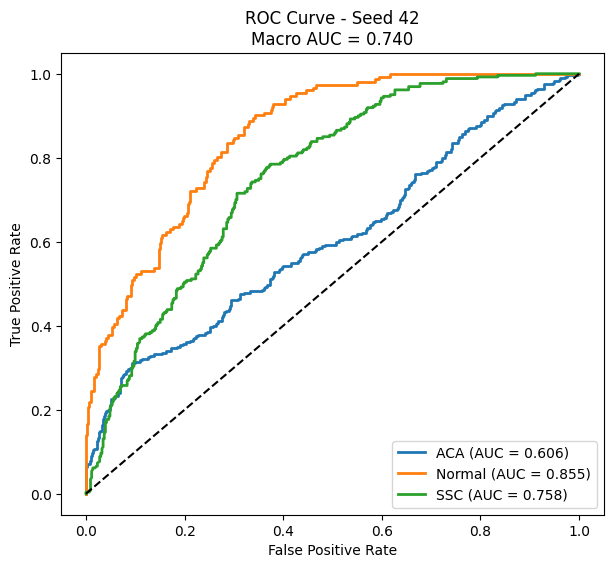

Seed 42 Macro AUC: 0.7396
{'ACA': np.float64(0.6064650677789364), 'Normal': np.float64(0.8545131223939171), 'SSC': np.float64(0.7577369266464393)}
True label distribution
(array([0, 1, 2]), array([280, 151, 260]))

Predicted label distribution
(array([0, 1, 2]), array([196,  23, 472]))

Confusion Matrix
[[112   1 167]
 [ 57  22  72]
 [ 27   0 233]]


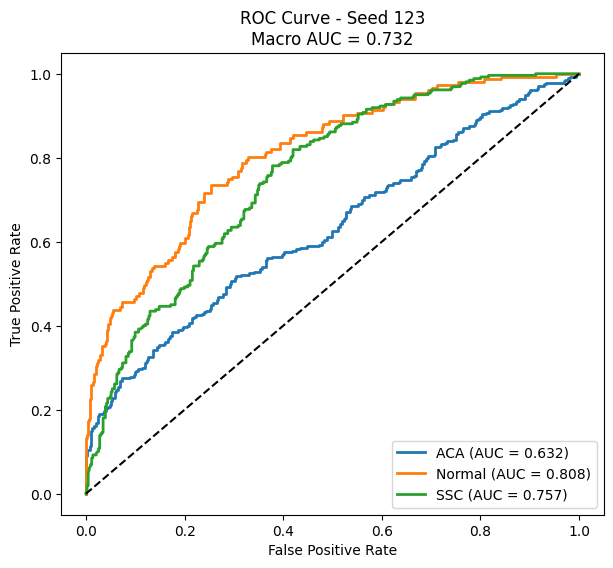

Seed 123 Macro AUC: 0.7325
{'ACA': np.float64(0.6323340285019117), 'Normal': np.float64(0.808008339465293), 'SSC': np.float64(0.7571033374977689)}
True label distribution
(array([0, 1, 2]), array([280, 151, 260]))

Predicted label distribution
(array([0, 1, 2]), array([223,  14, 454]))

Confusion Matrix
[[117   0 163]
 [ 70  14  67]
 [ 36   0 224]]


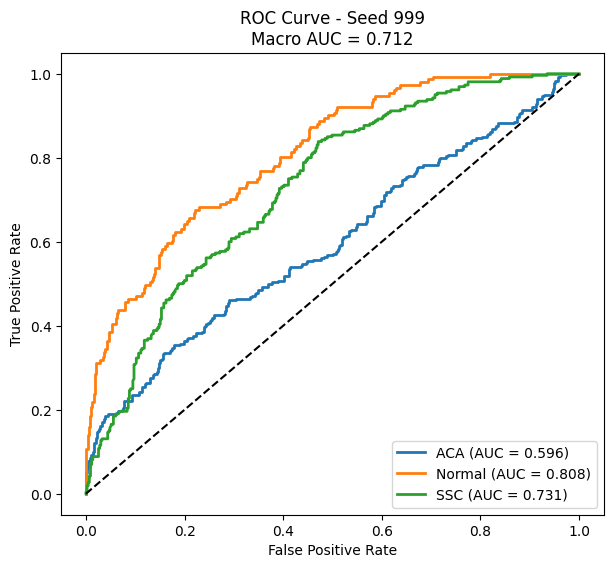

Seed 999 Macro AUC: 0.7118
{'ACA': np.float64(0.5963590545707333), 'Normal': np.float64(0.8077507971547706), 'SSC': np.float64(0.7313046582188114)}
True label distribution
(array([0, 1, 2]), array([280, 151, 260]))

Predicted label distribution
(array([0, 1, 2]), array([169,  14, 508]))

Confusion Matrix
[[ 92   0 188]
 [ 59  14  78]
 [ 18   0 242]]


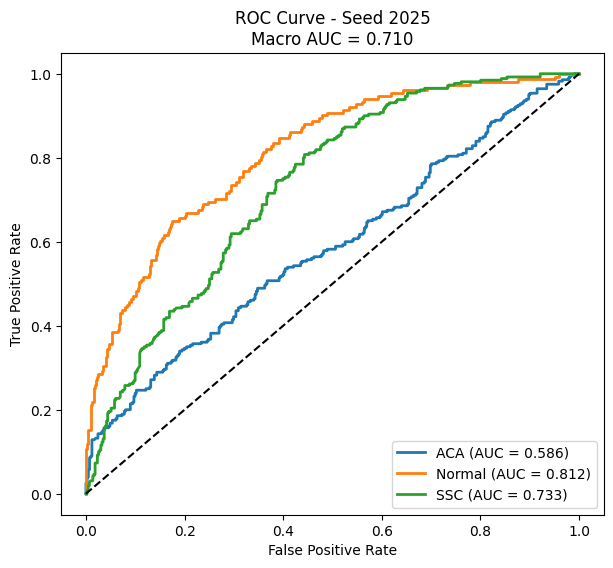

Seed 2025 Macro AUC: 0.7102
{'ACA': np.float64(0.5861444212721585), 'Normal': np.float64(0.8117610988471915), 'SSC': np.float64(0.7328127788684633)}
True label distribution
(array([0, 1, 2]), array([280, 151, 260]))

Predicted label distribution
(array([0, 1, 2]), array([199,  25, 467]))

Confusion Matrix
[[109   3 168]
 [ 62  22  67]
 [ 28   0 232]]


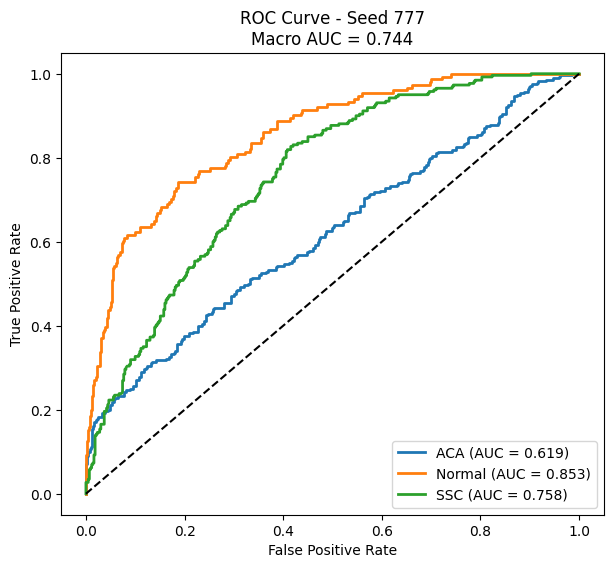

Seed 777 Macro AUC: 0.7437
{'ACA': np.float64(0.6191432047271463), 'Normal': np.float64(0.8534952170713761), 'SSC': np.float64(0.7583839014813493)}


In [70]:
results = []

for seed in SEEDS:

    # Load model
    weights = ConvNeXt_Tiny_Weights.DEFAULT
    model = convnext_tiny(weights=weights)

    num_features = model.classifier[2].in_features
    model.classifier[2] = nn.Linear(num_features, 3)

    model.load_state_dict(
        torch.load(
            f"best_convnext_tiny_seed_{seed}.pth",
            map_location=device
        )
    )

    model = model.to(device)
    model.eval()

    # Metrics
    acc, bal_acc, prec, rec, f1, mcc, kappa, cm = evaluate(
        model,
        external_loader
    )

    # ROC Curve
    class_names = ["ACA", "Normal", "SSC"]

    macro_auc, class_auc = plot_multiclass_roc(
        model,
        external_loader,
        class_names,
        seed
    )

    print(f"Seed {seed} Macro AUC: {macro_auc:.4f}")
    print(class_auc)

    results.append({
        "Seed": seed,
        "Accuracy": acc*100,
        "Balanced Accuracy": bal_acc*100,
        "Precision": prec*100,
        "Recall": rec*100,
        "F1-score": f1*100,
        "MCC": mcc,
        "Kappa": kappa,
        "Macro AUC": macro_auc
    })

In [68]:
results.append({
    "Seed": seed,
    "Accuracy": acc*100,
    "Balanced Accuracy": bal_acc*100,
    "Precision": prec*100,
    "Recall": rec*100,
    "F1-score": f1*100,
    "MCC": mcc,
    "Kappa": kappa,
    "Macro AUC": macro_auc
})

In [69]:
metrics = [
    "Accuracy",
    "Balanced Accuracy",
    "Precision",
    "Recall",
    "F1-score",
    "MCC",
    "Kappa",
    "Macro AUC"
]

In [22]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from torchvision import datasets
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    cohen_kappa_score,
    confusion_matrix
)

# ---------------------------------------------------
# External Dataset
# ---------------------------------------------------

external_dataset_path = "/kaggle/input/datasets/abdullahhasansajjad/lunghist700"

external_dataset = datasets.ImageFolder(
    root=external_dataset_path,
    transform=test_transform
)

external_loader = DataLoader(
    external_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(external_dataset.classes)
print(len(external_dataset))

['LungHist700_combined']
691


In [23]:
def get_model():

    weights = ConvNeXt_Tiny_Weights.DEFAULT

    model = convnext_tiny(weights=weights)

    num_features = model.classifier[2].in_features

    model.classifier[2] = nn.Linear(
        num_features,
        3
    )

    return model.to(device)

In [24]:
external_dataset_path = "/kaggle/input/datasets/abdullahhasansajjad/lunghist700/LungHist700_combined/data/images"

In [25]:
external_dataset = datasets.ImageFolder(
    root=external_dataset_path,
    transform=test_transform
)

print(external_dataset.classes)
print(external_dataset.class_to_idx)

['aca', 'nor', 'ssc']
{'aca': 0, 'nor': 1, 'ssc': 2}


In [26]:
print(lc_dataset.classes)
print(lc_dataset.class_to_idx)

['adenocarcinoma', 'benign', 'squamous_cell_carcinoma']
{'adenocarcinoma': 0, 'benign': 1, 'squamous_cell_carcinoma': 2}


In [27]:
print(lc_dataset.class_to_idx)
print(external_dataset.class_to_idx)

{'adenocarcinoma': 0, 'benign': 1, 'squamous_cell_carcinoma': 2}
{'aca': 0, 'nor': 1, 'ssc': 2}


In [28]:
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights
import torch.nn as nn

def get_model():

    model = convnext_tiny(weights=None)

    num_features = model.classifier[2].in_features

    model.classifier[2] = nn.Linear(num_features, 3)

    return model.to(device)

In [29]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    cohen_kappa_score,
    confusion_matrix
)

def evaluate(model, loader):

    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            preds = torch.argmax(outputs, dim=1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    acc = accuracy_score(y_true, y_pred)
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    mcc = matthews_corrcoef(y_true, y_pred)
    kappa = cohen_kappa_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)

    return acc, bal_acc, precision, recall, f1, mcc, kappa, cm

In [30]:
print(len(external_dataset))
print(external_dataset.classes)
print(external_dataset.class_to_idx)

import numpy as np

labels = [label for _, label in external_dataset.samples]

print(np.unique(labels, return_counts=True))

691
['aca', 'nor', 'ssc']
{'aca': 0, 'nor': 1, 'ssc': 2}
(array([0, 1, 2]), array([280, 151, 260]))


In [31]:
import numpy as np
import torch

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    cohen_kappa_score,
    confusion_matrix
)

def evaluate(model, loader):

    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)

            outputs = model(images)

            preds = torch.argmax(outputs, dim=1)

            y_true.extend(labels.numpy().tolist())
            y_pred.extend(preds.cpu().numpy().tolist())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # ---------------- Debug ----------------
    print("="*60)
    print("True label distribution")
    print(np.unique(y_true, return_counts=True))

    print("\nPredicted label distribution")
    print(np.unique(y_pred, return_counts=True))

    print("\nConfusion Matrix")
    cm = confusion_matrix(y_true, y_pred)
    print(cm)
    print("="*60)

    # ---------------- Metrics ----------------
    acc = accuracy_score(y_true, y_pred)

    bal_acc = balanced_accuracy_score(
        y_true,
        y_pred
    )

    precision = precision_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    mcc = matthews_corrcoef(
        y_true,
        y_pred
    )

    kappa = cohen_kappa_score(
        y_true,
        y_pred
    )

    return (
        acc,
        bal_acc,
        precision,
        recall,
        f1,
        mcc,
        kappa,
        cm
    )

In [32]:
import pandas as pd
import numpy as np

SEEDS = [42, 123, 999, 2025, 777]

results = []

for seed in SEEDS:

    print(f"\nEvaluating Seed {seed}")

    model = get_model()
    model.load_state_dict(
        torch.load(
            f"best_convnext_tiny_seed_{seed}.pth",
            map_location=device
        )
    )
    model.to(device)

    acc, bal_acc, precision, recall, f1, mcc, kappa, cm = evaluate(
        model,
        external_loader
    )

    results.append({
        "Seed": seed,
        "Accuracy": acc * 100,
        "Balanced Accuracy": bal_acc * 100,
        "Precision": precision * 100,
        "Recall": recall * 100,
        "F1-score": f1 * 100,
        "MCC": mcc,
        "Cohen's Kappa": kappa
    })

    print(cm)

results_df = pd.DataFrame(results)

print("\nPer-seed Results")
display(results_df)


Evaluating Seed 42
True label distribution
(array([0]), array([691]))

Predicted label distribution
(array([0, 1, 2]), array([117,  32, 542]))

Confusion Matrix
[[117  32 542]
 [  0   0   0]
 [  0   0   0]]
[[117  32 542]
 [  0   0   0]
 [  0   0   0]]

Evaluating Seed 123
True label distribution
(array([0]), array([691]))

Predicted label distribution
(array([0, 1, 2]), array([196,  23, 472]))

Confusion Matrix
[[196  23 472]
 [  0   0   0]
 [  0   0   0]]
[[196  23 472]
 [  0   0   0]
 [  0   0   0]]

Evaluating Seed 999
True label distribution
(array([0]), array([691]))

Predicted label distribution
(array([0, 1, 2]), array([223,  14, 454]))

Confusion Matrix
[[223  14 454]
 [  0   0   0]
 [  0   0   0]]
[[223  14 454]
 [  0   0   0]
 [  0   0   0]]

Evaluating Seed 2025
True label distribution
(array([0]), array([691]))

Predicted label distribution
(array([0, 1, 2]), array([169,  14, 508]))

Confusion Matrix
[[169  14 508]
 [  0   0   0]
 [  0   0   0]]
[[169  14 508]
 [  0   0  

,Seed,Accuracy,Balanced Accuracy,Precision,Recall,F1-score,MCC,Cohen's Kappa
0,42,16.931983,16.931983,100.0,16.931983,28.960396,0.0,0.0
1,123,28.364689,28.364689,100.0,28.364689,44.193912,0.0,0.0
2,999,32.272069,32.272069,100.0,32.272069,48.796499,0.0,0.0
3,2025,24.457308,24.457308,100.0,24.457308,39.302326,0.0,0.0
4,777,28.798842,28.798842,100.0,28.798842,44.719101,0.0,0.0


In [33]:
print(results_df.columns)

Index(['Seed', 'Accuracy', 'Balanced Accuracy', 'Precision', 'Recall',
       'F1-score', 'MCC', 'Cohen's Kappa'],
      dtype='object')


In [95]:
summary = pd.DataFrame({
    "Metric": [
        "Accuracy (%)",
        "Balanced Accuracy (%)",
        "Precision (%)",
        "Recall (%)",
        "F1-score (%)",
        "MCC",
        "Cohen's Kappa"
    ],
    "Mean ± SD": [
        f"{results_df['Accuracy'].mean():.2f} ± {results_df['Accuracy'].std(ddof=1):.2f}",
        f"{results_df['Balanced Accuracy'].mean():.2f} ± {results_df['Balanced Accuracy'].std(ddof=1):.2f}",
        f"{results_df['Precision'].mean():.2f} ± {results_df['Precision'].std(ddof=1):.2f}",
        f"{results_df['Recall'].mean():.2f} ± {results_df['Recall'].std(ddof=1):.2f}",
        f"{results_df['F1-score'].mean():.2f} ± {results_df['F1-score'].std(ddof=1):.2f}",
        f"{results_df['MCC'].mean():.4f} ± {results_df['MCC'].std(ddof=1):.4f}",
        f"{results_df["Cohen's Kappa"].mean():.4f} ± {results_df["Cohen's Kappa"].std(ddof=1):.4f}"
    ]
})

display(summary)

,Metric,Mean ± SD
0,Accuracy (%),52.01 ± 1.12
1,Balanced Accuracy (%),47.03 ± 1.55
2,Precision (%),62.53 ± 2.34
3,Recall (%),52.01 ± 1.12
4,F1-score (%),46.84 ± 1.80
5,MCC,0.2705 ± 0.0325
6,Cohen's Kappa,0.2273 ± 0.0204


In [34]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from torchvision import datasets
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    cohen_kappa_score,
    confusion_matrix
)

# ---------------------------------------------------
# External Dataset
# ---------------------------------------------------

external_dataset_path = "/kaggle/input/datasets/abdullahhasansajjad/lunghist700"

external_dataset = datasets.ImageFolder(
    root=external_dataset_path,
    transform=test_transform
)

external_loader = DataLoader(
    external_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(external_dataset.classes)
print(len(external_dataset))

['LungHist700_combined']
691


In [35]:
def get_model():

    weights = ConvNeXt_Tiny_Weights.DEFAULT

    model = convnext_tiny(weights=weights)

    num_features = model.classifier[2].in_features

    model.classifier[2] = nn.Linear(
        num_features,
        3
    )

    return model.to(device)

In [36]:
external_dataset_path = "/kaggle/input/datasets/abdullahhasansajjad/lunghist700/LungHist700_combined/data/images"

In [37]:
external_dataset = datasets.ImageFolder(
    root=external_dataset_path,
    transform=test_transform
)

print(external_dataset.classes)
print(external_dataset.class_to_idx)

['aca', 'nor', 'ssc']
{'aca': 0, 'nor': 1, 'ssc': 2}


In [38]:
print(lc_dataset.classes)
print(lc_dataset.class_to_idx)

['adenocarcinoma', 'benign', 'squamous_cell_carcinoma']
{'adenocarcinoma': 0, 'benign': 1, 'squamous_cell_carcinoma': 2}


In [39]:
print(lc_dataset.class_to_idx)
print(external_dataset.class_to_idx)

{'adenocarcinoma': 0, 'benign': 1, 'squamous_cell_carcinoma': 2}
{'aca': 0, 'nor': 1, 'ssc': 2}


In [40]:
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights
import torch.nn as nn

def get_model():

    model = convnext_tiny(weights=None)

    num_features = model.classifier[2].in_features

    model.classifier[2] = nn.Linear(num_features, 3)

    return model.to(device)

In [41]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    cohen_kappa_score,
    confusion_matrix
)

def evaluate(model, loader):

    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            preds = torch.argmax(outputs, dim=1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    acc = accuracy_score(y_true, y_pred)
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    mcc = matthews_corrcoef(y_true, y_pred)
    kappa = cohen_kappa_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)

    return acc, bal_acc, precision, recall, f1, mcc, kappa, cm

In [42]:
print(len(external_dataset))
print(external_dataset.classes)
print(external_dataset.class_to_idx)

import numpy as np

labels = [label for _, label in external_dataset.samples]

print(np.unique(labels, return_counts=True))

691
['aca', 'nor', 'ssc']
{'aca': 0, 'nor': 1, 'ssc': 2}
(array([0, 1, 2]), array([280, 151, 260]))


In [43]:
import numpy as np
import torch

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    cohen_kappa_score,
    confusion_matrix
)

def evaluate(model, loader):

    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)

            outputs = model(images)

            preds = torch.argmax(outputs, dim=1)

            y_true.extend(labels.numpy().tolist())
            y_pred.extend(preds.cpu().numpy().tolist())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # ---------------- Debug ----------------
    print("="*60)
    print("True label distribution")
    print(np.unique(y_true, return_counts=True))

    print("\nPredicted label distribution")
    print(np.unique(y_pred, return_counts=True))

    print("\nConfusion Matrix")
    cm = confusion_matrix(y_true, y_pred)
    print(cm)
    print("="*60)

    # ---------------- Metrics ----------------
    acc = accuracy_score(y_true, y_pred)

    bal_acc = balanced_accuracy_score(
        y_true,
        y_pred
    )

    precision = precision_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    mcc = matthews_corrcoef(
        y_true,
        y_pred
    )

    kappa = cohen_kappa_score(
        y_true,
        y_pred
    )

    return (
        acc,
        bal_acc,
        precision,
        recall,
        f1,
        mcc,
        kappa,
        cm
    )

In [45]:
print(external_dataset.class_to_idx)
print(len(external_dataset))

labels = [label for _, label in external_dataset]

print(np.unique(labels, return_counts=True))

{'aca': 0, 'nor': 1, 'ssc': 2}
691
(array([0, 1, 2]), array([280, 151, 260]))


In [46]:
all_labels = []

for _, labels in external_loader:
    all_labels.extend(labels.numpy())

print(np.unique(all_labels, return_counts=True))

(array([0]), array([691]))


In [98]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

lc25000_test_dataset = datasets.ImageFolder(
    root="/kaggle/input/datasets/rm1000/lung-cancer-histopathological-images",   # <-- change this
    transform=test_transform
)

lc25000_test_loader = DataLoader(
    lc25000_test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(lc25000_test_dataset.class_to_idx)

{'adenocarcinoma': 0, 'benign': 1, 'squamous_cell_carcinoma': 2}


In [99]:
import pandas as pd
import torch

SEEDS = [42, 123, 999, 2025, 777]

results = []

for seed in SEEDS:

    print(f"\nEvaluating Seed {seed}")

    model = get_model()

    model.load_state_dict(
        torch.load(
            f"best_convnext_tiny_seed_{seed}.pth",
            map_location=device
        )
    )

    model.to(device)

    acc, bal_acc, precision, recall, f1, mcc, kappa, cm = evaluate(
        model,
        lc25000_test_loader
    )

    results.append({
        "Seed": seed,
        "Accuracy": acc*100,
        "Balanced Accuracy": bal_acc*100,
        "Precision": precision*100,
        "Recall": recall*100,
        "F1-score": f1*100,
        "MCC": mcc,
        "Kappa": kappa
    })

results_df = pd.DataFrame(results)

display(results_df)


Evaluating Seed 42
True label distribution
(array([0, 1, 2]), array([5000, 5000, 5000]))

Predicted label distribution
(array([0, 1, 2]), array([4998, 5000, 5002]))

Confusion Matrix
[[4998    0    2]
 [   0 5000    0]
 [   0    0 5000]]

Evaluating Seed 123
True label distribution
(array([0, 1, 2]), array([5000, 5000, 5000]))

Predicted label distribution
(array([0, 1, 2]), array([4999, 5000, 5001]))

Confusion Matrix
[[4999    0    1]
 [   0 5000    0]
 [   0    0 5000]]

Evaluating Seed 999
True label distribution
(array([0, 1, 2]), array([5000, 5000, 5000]))

Predicted label distribution
(array([0, 1, 2]), array([4997, 5000, 5003]))

Confusion Matrix
[[4997    0    3]
 [   0 5000    0]
 [   0    0 5000]]

Evaluating Seed 2025
True label distribution
(array([0, 1, 2]), array([5000, 5000, 5000]))

Predicted label distribution
(array([0, 1, 2]), array([5000, 5000, 5000]))

Confusion Matrix
[[5000    0    0]
 [   0 5000    0]
 [   0    0 5000]]

Evaluating Seed 777
True label distribu

,Seed,Accuracy,Balanced Accuracy,Precision,Recall,F1-score,MCC,Kappa
0,42,99.986667,99.986667,99.986672,99.986667,99.986667,0.9998,0.9998
1,123,99.993333,99.993333,99.993335,99.993333,99.993333,0.9999,0.9999
2,999,99.980000,99.980000,99.980012,99.980000,99.980000,0.9997,0.9997
3,2025,100.000000,100.000000,100.000000,100.000000,100.000000,1.0000,1.0000
4,777,99.980000,99.980000,99.980012,99.980000,99.980000,0.9997,0.9997


In [100]:
summary = pd.DataFrame({
    "Metric":[
        "Accuracy (%)",
        "Balanced Accuracy (%)",
        "Precision (%)",
        "Recall (%)",
        "F1-score (%)",
        "MCC",
        "Cohen's Kappa"
    ],
    "Mean ± SD":[
        f"{results_df['Accuracy'].mean():.2f} ± {results_df['Accuracy'].std(ddof=1):.2f}",
        f"{results_df['Balanced Accuracy'].mean():.2f} ± {results_df['Balanced Accuracy'].std(ddof=1):.2f}",
        f"{results_df['Precision'].mean():.2f} ± {results_df['Precision'].std(ddof=1):.2f}",
        f"{results_df['Recall'].mean():.2f} ± {results_df['Recall'].std(ddof=1):.2f}",
        f"{results_df['F1-score'].mean():.2f} ± {results_df['F1-score'].std(ddof=1):.2f}",
        f"{results_df['MCC'].mean():.4f} ± {results_df['MCC'].std(ddof=1):.4f}",
        f"{results_df['Kappa'].mean():.4f} ± {results_df['Kappa'].std(ddof=1):.4f}"
    ]
})

display(summary)

,Metric,Mean ± SD
0,Accuracy (%),99.99 ± 0.01
1,Balanced Accuracy (%),99.99 ± 0.01
2,Precision (%),99.99 ± 0.01
3,Recall (%),99.99 ± 0.01
4,F1-score (%),99.99 ± 0.01
5,MCC,0.9998 ± 0.0001
6,Cohen's Kappa,0.9998 ± 0.0001


In [101]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

In [102]:
def plot_confusion_matrix(cm, class_names, title):

    fig, ax = plt.subplots(figsize=(6, 6))

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_names
    )

    disp.plot(
        cmap="Blues",
        values_format="d",
        ax=ax,
        colorbar=False
    )

    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.set_xlabel("Predicted Label", fontsize=12)
    ax.set_ylabel("True Label", fontsize=12)

    plt.tight_layout()
    plt.show()

True label distribution
(array([0, 1, 2]), array([5000, 5000, 5000]))

Predicted label distribution
(array([0, 1, 2]), array([4998, 5000, 5002]))

Confusion Matrix
[[4998    0    2]
 [   0 5000    0]
 [   0    0 5000]]


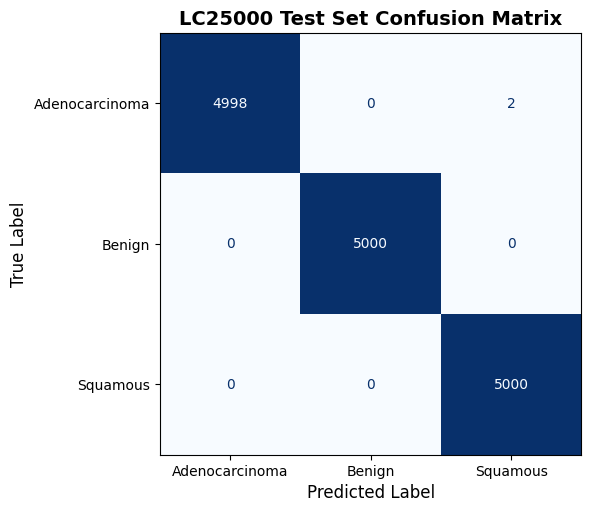

In [103]:
model = get_model()

model.load_state_dict(
    torch.load(
        "best_convnext_tiny_seed_42.pth",
        map_location=device
    )
)

_, _, _, _, _, _, _, cm_lc = evaluate(
    model,
    lc25000_test_loader
)

plot_confusion_matrix(
    cm_lc,
    ["Adenocarcinoma", "Benign", "Squamous"],
    "LC25000 Test Set Confusion Matrix"
)

True label distribution
(array([0, 1, 2]), array([280, 151, 260]))

Predicted label distribution
(array([0, 1, 2]), array([117,  32, 542]))

Confusion Matrix
[[ 82   2 196]
 [ 27  30  94]
 [  8   0 252]]


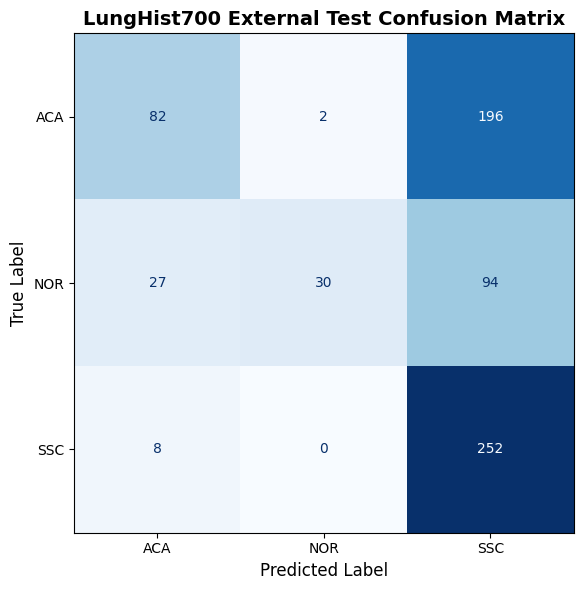

In [104]:
_, _, _, _, _, _, _, cm_external = evaluate(
    model,
    external_loader
)

plot_confusion_matrix(
    cm_external,
    ["ACA", "NOR", "SSC"],
    "LungHist700 External Test Confusion Matrix"
)

In [105]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

In [106]:
def plot_multiclass_roc(model, loader, class_names, title, save_path=None):

    model.eval()

    y_true = []
    y_score = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)

            outputs = model(images)

            probs = torch.softmax(outputs, dim=1)

            y_true.extend(labels.cpu().numpy())
            y_score.extend(probs.cpu().numpy())

    y_true = np.array(y_true)
    y_score = np.array(y_score)

    n_classes = len(class_names)

    y_true_bin = label_binarize(y_true, classes=np.arange(n_classes))

    plt.figure(figsize=(7,7))

    colors = ["blue","green","red","orange","purple","brown"]

    auc_scores = []

    for i in range(n_classes):

        fpr, tpr, _ = roc_curve(
            y_true_bin[:, i],
            y_score[:, i]
        )

        roc_auc = auc(fpr, tpr)

        auc_scores.append(roc_auc)

        plt.plot(
            fpr,
            tpr,
            lw=2,
            color=colors[i],
            label=f"{class_names[i]} (AUC = {roc_auc:.4f})"
        )

    plt.plot(
        [0,1],
        [0,1],
        'k--',
        lw=1
    )

    plt.xlim([0.0,1.0])
    plt.ylim([0.0,1.05])

    plt.xlabel("False Positive Rate", fontsize=12)
    plt.ylabel("True Positive Rate", fontsize=12)
    plt.title(title, fontsize=14, fontweight="bold")

    plt.legend(loc="lower right")

    plt.grid(alpha=0.3)

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300)

    plt.show()

    print(f"Macro AUC : {np.mean(auc_scores):.4f}")

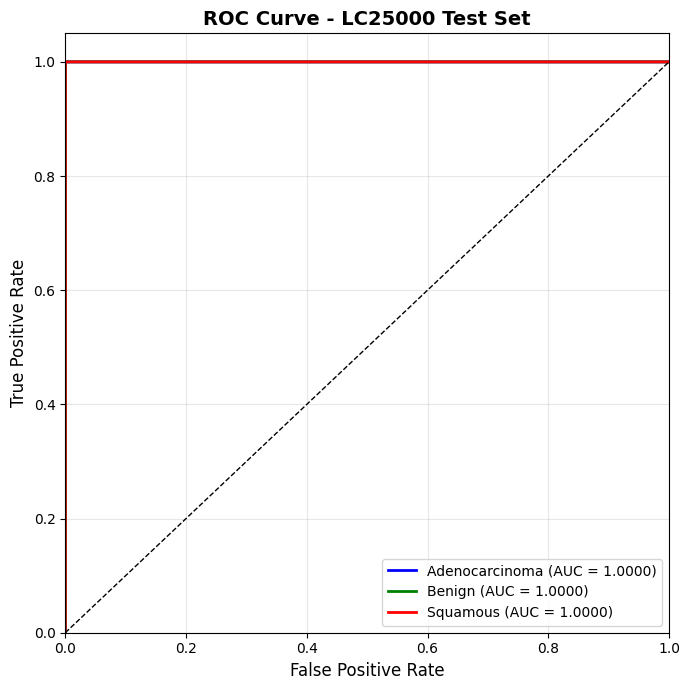

Macro AUC : 1.0000


In [107]:
model = get_model()

model.load_state_dict(
    torch.load(
        "best_convnext_tiny_seed_42.pth",
        map_location=device
    )
)

model.to(device)

plot_multiclass_roc(
    model,
    lc25000_test_loader,
    [
        "Adenocarcinoma",
        "Benign",
        "Squamous"
    ],
    "ROC Curve - LC25000 Test Set",
    "ROC_LC25000.png"
)

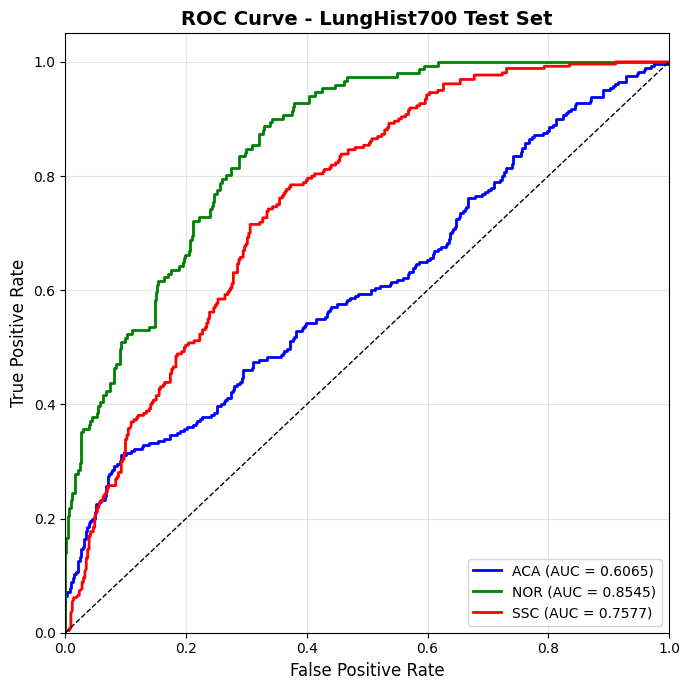

Macro AUC : 0.7396


In [108]:
plot_multiclass_roc(
    model,
    external_loader,
    [
        "ACA",
        "NOR",
        "SSC"
    ],
    "ROC Curve - LungHist700 Test Set",
    "ROC_LungHist700.png"
)

In [ ]:
plot_multiclass_roc(
    model,
    external_loader,
    [
        "ACA",
        "NOR",
        "SSC"
    ],
    "ROC Curve - LungHist700 Test Set",
    "ROC_LungHist700.png"
)

In [97]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rm1000/lung-cancer-histopathological-images")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/rm1000/lung-cancer-histopathological-images


In [65]:
all_labels = []

for _, labels in external_loader:
    all_labels.extend(labels.numpy())

import numpy as np

print(np.unique(all_labels, return_counts=True))

(array([0]), array([691]))


In [69]:
import os

root = "/kaggle/input/datasets/abdullahhasansajjad/lunghist700"

print(os.listdir(root))

['LungHist700_combined']


In [70]:
print(os.listdir("/kaggle/input/datasets/abdullahhasansajjad/lunghist700/LungHist700_combined"))

['data']


In [71]:
print(os.listdir("/kaggle/input/datasets/abdullahhasansajjad/lunghist700/LungHist700_combined/data"))

['images', 'data.csv']


In [79]:
print(os.listdir("/kaggle/input/datasets/abdullahhasansajjad/lunghist700/LungHist700_combined/data/images"))

['aca', 'ssc', 'nor']


In [80]:
from torchvision.datasets import ImageFolder
import numpy as np

external_dataset = ImageFolder(
    root="/kaggle/input/datasets/abdullahhasansajjad/lunghist700/LungHist700_combined/data/images",
    transform=test_transform
)

print(external_dataset.classes)
print(external_dataset.class_to_idx)

labels = [label for _, label in external_dataset.samples]
print(np.unique(labels, return_counts=True))

['aca', 'nor', 'ssc']
{'aca': 0, 'nor': 1, 'ssc': 2}
(array([0, 1, 2]), array([280, 151, 260]))


In [81]:
from torch.utils.data import DataLoader

external_loader = DataLoader(
    external_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [82]:
labels = [label for _, label in external_loader.dataset.samples]
print(np.unique(labels, return_counts=True))

(array([0, 1, 2]), array([280, 151, 260]))


In [83]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    matthews_corrcoef,
    cohen_kappa_score
)

def evaluate(model, loader):

    model.eval()

    y_true = []
    y_pred = []
    y_prob = []

    with torch.no_grad():

        for images, labels in tqdm(loader):

            images = images.to(device)

            outputs = model(images)

            probs = torch.softmax(outputs, dim=1)

            preds = torch.argmax(outputs, 1)

            y_true.extend(labels.numpy())

            y_pred.extend(preds.cpu().numpy())

            y_prob.extend(probs.cpu().numpy())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_prob = np.array(y_prob)

    acc = accuracy_score(y_true, y_pred)

    bal_acc = balanced_accuracy_score(
        y_true,
        y_pred
    )

    precision = precision_score(
        y_true,
        y_pred,
        average="weighted"
    )

    recall = recall_score(
        y_true,
        y_pred,
        average="weighted"
    )

    f1 = f1_score(
        y_true,
        y_pred,
        average="weighted"
    )

    mcc = matthews_corrcoef(
        y_true,
        y_pred
    )

    kappa = cohen_kappa_score(
        y_true,
        y_pred
    )

    # Print metrics
    print(f"\nAccuracy : {acc:.4f}")
    print(f"Balanced Accuracy : {bal_acc:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall : {recall:.4f}")
    print(f"F1-score : {f1:.4f}")
    print(f"MCC : {mcc:.4f}")
    print(f"Cohen's Kappa : {kappa:.4f}")

    print("\nClassification Report\n")
    print(classification_report(y_true, y_pred))

    return y_true, y_pred, y_prob

In [24]:
print("="*60)
print("LC25000 TEST")
print("="*60)

y_true_lc,\
y_pred_lc,\
y_prob_lc = evaluate(
    model,
    test_loader
)

LC25000 TEST


  0%|          | 0/71 [00:00<?, ?it/s]


Accuracy : 1.0000
Balanced Accuracy : 1.0000
Precision : 1.0000
Recall : 1.0000
F1-score : 1.0000
MCC : 1.0000
Cohen's Kappa : 1.0000

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       734
           1       1.00      1.00      1.00       728
           2       1.00      1.00      1.00       788

    accuracy                           1.00      2250
   macro avg       1.00      1.00      1.00      2250
weighted avg       1.00      1.00      1.00      2250



In [26]:
print("="*60)
print("LUNGHIST700 EXTERNAL TEST")
print("="*60)

y_true_ext,\
y_pred_ext,\
y_prob_ext = evaluate(
    model,
    lunghist_loader
)

LUNGHIST700 EXTERNAL TEST


  0%|          | 0/22 [00:00<?, ?it/s]


Accuracy : 0.5297
Balanced Accuracy : 0.4895
Precision : 0.6310
Recall : 0.5297
F1-score : 0.4856
MCC : 0.3036
Cohen's Kappa : 0.2483

Classification Report

              precision    recall  f1-score   support

           0       0.64      0.33      0.43       280
           1       0.89      0.21      0.33       151
           2       0.47      0.93      0.63       260

    accuracy                           0.53       691
   macro avg       0.67      0.49      0.47       691
weighted avg       0.63      0.53      0.49       691



In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_cm(y_true,y_pred,title):

    cm = confusion_matrix(y_true,y_pred)

    plt.figure(figsize=(6,5))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap="Blues",
        xticklabels=["ACA","NOR","SSC"],
        yticklabels=["ACA","NOR","SSC"]
    )

    plt.xlabel("Predicted")

    plt.ylabel("True")

    plt.title(title)

    plt.show()

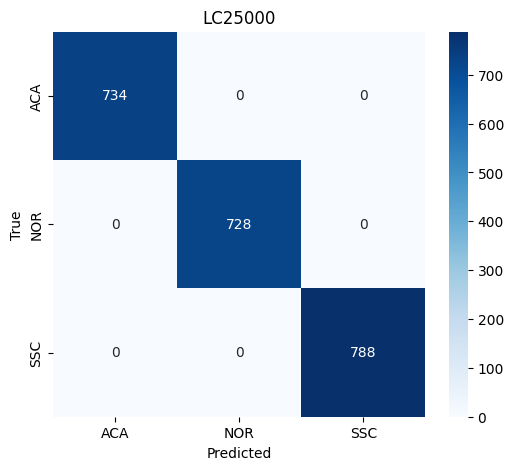

In [28]:
plot_cm(
    y_true_lc,
    y_pred_lc,
    "LC25000"
)

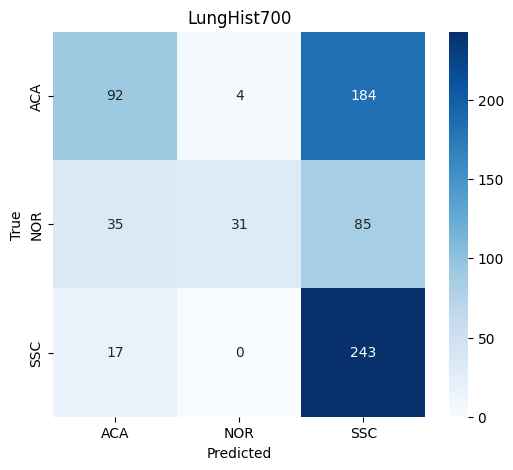

In [29]:
plot_cm(
    y_true_ext,
    y_pred_ext,
    "LungHist700"
)

In [37]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

def plot_roc(y_true,y_prob,title):

    classes = 3

    y_true_bin = label_binarize(
        y_true,
        classes=[0,1,2]
    )

    plt.figure(figsize=(7,6))

    for i in range(classes):

        fpr,tpr,_ = roc_curve(
            y_true_bin[:,i],
            y_prob[:,i]
        )

        roc_auc = auc(fpr,tpr)

        plt.plot(
            fpr,
            tpr,
            lw=2,
            label=f"Class {i} AUC={roc_auc:.3f}"
        )

    plt.plot([0,1],[0,1],'k--')

    plt.legend()

    plt.title(title)

    plt.xlabel("False Positive Rate")

    plt.ylabel("True Positive Rate")

    plt.show()

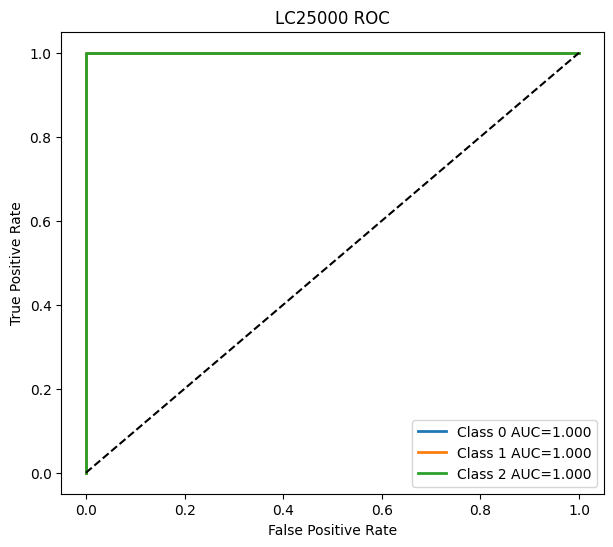

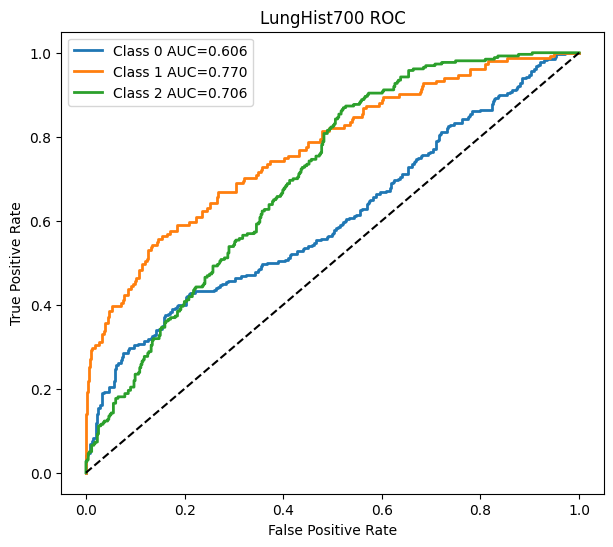

In [38]:
plot_roc(
    y_true_lc,
    y_prob_lc,
    "LC25000 ROC"
)

plot_roc(
    y_true_ext,
    y_prob_ext,
    "LungHist700 ROC"
)

**# SWIN TINY STARTS**

In [2]:
SEEDS = [42, 123, 999, 2025, 777]

def set_seed(seed):

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [3]:
LC25000_PATH = "/kaggle/input/datasets/rm1000/lung-cancer-histopathological-images"

LUNGHIST700_PATH = "/kaggle/input/datasets/abdullahhasansajjad/lunghist700"

In [7]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [8]:
from torchvision.datasets import ImageFolder
from torch.utils.data import random_split

# ---------------------------------
# LC25000 Dataset
# ---------------------------------

lc_dataset = ImageFolder(
    root=LC25000_PATH,
    transform=train_transform
)

print("Classes :", lc_dataset.classes)
print("Class mapping :", lc_dataset.class_to_idx)
print("Total Images :", len(lc_dataset))

Classes : ['adenocarcinoma', 'benign', 'squamous_cell_carcinoma']
Class mapping : {'adenocarcinoma': 0, 'benign': 1, 'squamous_cell_carcinoma': 2}
Total Images : 15000


In [9]:
train_size = int(0.70 * len(lc_dataset))
val_size = int(0.15 * len(lc_dataset))
test_size = len(lc_dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    lc_dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

# validation/test should not use augmentation
val_dataset.dataset.transform = test_transform
test_dataset.dataset.transform = test_transform

print(len(train_dataset))
print(len(val_dataset))
print(len(test_dataset))

10500
2250
2250


In [10]:
SEEDS = [42, 123, 999, 2025, 777]

for seed in SEEDS:
    print(f"\nRunning with seed {seed}")

    set_seed(seed)

    train_dataset, val_dataset, test_dataset = random_split(
        lc_dataset,
        [train_size, val_size, test_size],
        generator=torch.Generator().manual_seed(seed)
    )

    val_dataset.dataset.transform = test_transform
    test_dataset.dataset.transform = test_transform

    # Create dataloaders
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

    # Train model here


Running with seed 42

Running with seed 123

Running with seed 999

Running with seed 2025

Running with seed 777


In [11]:
lunghist_dataset = ImageFolder(
    root="/kaggle/input/datasets/abdullahhasansajjad/lunghist700/LungHist700_combined/data/images",
    transform=test_transform
)

print(lunghist_dataset.classes)
print(lunghist_dataset.class_to_idx)
print("Total Images :", len(lunghist_dataset))

['aca', 'nor', 'ssc']
{'aca': 0, 'nor': 1, 'ssc': 2}
Total Images : 691


In [12]:
from torch.utils.data import Dataset

class LungHist700Dataset(Dataset):

    def __init__(self, dataset):

        self.dataset = dataset

        self.mapping = {
            dataset.class_to_idx['aca']:0,
            dataset.class_to_idx['nor']:1,
            dataset.class_to_idx['ssc']:2
        }

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):

        image,label = self.dataset[idx]

        label = self.mapping[label]

        return image,label


lunghist_dataset = LungHist700Dataset(lunghist_dataset)

In [13]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

lunghist_loader = DataLoader(
    lunghist_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [14]:
from torchvision.models import swin_t, Swin_T_Weights

weights = Swin_T_Weights.DEFAULT

model = swin_t(weights=weights)

num_features = model.head.in_features

model.head = nn.Linear(num_features, 3)

model = model.to(device)

Downloading: "https://download.pytorch.org/models/swin_t-704ceda3.pth" to /root/.cache/torch/hub/checkpoints/swin_t-704ceda3.pth


100%|██████████| 108M/108M [00:00<00:00, 199MB/s] 


In [15]:
print(model)

SwinTransformer(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
      (1): Permute()
      (2): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
    )
    (1): Sequential(
      (0): SwinTransformerBlock(
        (norm1): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
        (attn): ShiftedWindowAttention(
          (qkv): Linear(in_features=96, out_features=288, bias=True)
          (proj): Linear(in_features=96, out_features=96, bias=True)
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
        (norm2): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
        (mlp): MLP(
          (0): Linear(in_features=96, out_features=384, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=384, out_features=96, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (1): SwinTransformerBlock(
       

In [18]:
criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler = CosineAnnealingLR(
    optimizer,
    T_max=20
)

scaler = torch.cuda.amp.GradScaler()

In [19]:
class EarlyStopping:

    def __init__(self, patience=7):

        self.patience = patience

        self.counter = 0

        self.best_loss = np.inf

        self.stop = False

    def __call__(self, val_loss):

        if val_loss < self.best_loss:

            self.best_loss = val_loss

            self.counter = 0

        else:

            self.counter += 1

            if self.counter >= self.patience:

                self.stop = True


early_stop = EarlyStopping(patience=7)

In [20]:
scaler = torch.amp.GradScaler("cuda")

In [21]:
def train_one_epoch(model, loader):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    loop = tqdm(loader)

    for images, labels in loop:

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        # Mixed Precision Forward Pass
        with torch.amp.autocast(device_type="cuda", dtype=torch.float16):
            outputs = model(images)
            loss = criterion(outputs, labels)

        # Backward Pass
        scaler.scale(loss).backward()

        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()

        _, preds = torch.max(outputs, 1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

        loop.set_postfix(
            loss=f"{loss.item():.4f}",
            acc=f"{100 * correct / total:.2f}%"
        )

    epoch_loss = running_loss / len(loader)
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [22]:
def validate(model, loader):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            # Mixed Precision Inference
            with torch.amp.autocast(device_type="cuda", dtype=torch.float16):
                outputs = model(images)
                loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, preds = torch.max(outputs, 1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / len(loader)
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [23]:
from torchvision.models import swin_t, Swin_T_Weights

weights = Swin_T_Weights.DEFAULT

model = swin_t(weights=weights)

num_features = model.head.in_features
model.head = nn.Linear(num_features, 3)

model = model.to(device)

In [24]:
model = swin_t(weights=weights)
model.head = nn.Linear(model.head.in_features, 3)
model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    patience=2
)

scaler = torch.amp.GradScaler("cuda")

In [47]:
NUM_EPOCHS = 10

best_acc = 0

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

for epoch in range(NUM_EPOCHS):

    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")

    train_loss, train_acc = train_one_epoch(model, train_loader)

    val_loss, val_acc = validate(model, val_loader)

    # Pass validation loss to ReduceLROnPlateau
    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Train Loss : {train_loss:.4f}")
    print(f"Train Acc  : {train_acc*100:.2f}%")

    print(f"Val Loss   : {val_loss:.4f}")
    print(f"Val Acc    : {val_acc*100:.2f}%")

    if val_acc > best_acc:

        best_acc = val_acc

        torch.save(
            model.state_dict(),
            "best_swin_tiny.pth"
        )

        print("Model Saved.")

    early_stop(val_loss)

    if early_stop.stop:
        print("Early stopping...")
        break

print("\nTraining Finished.")


Epoch 1/10


  0%|          | 0/329 [00:00<?, ?it/s]

Train Loss : 0.1246
Train Acc  : 94.87%
Val Loss   : 0.0481
Val Acc    : 98.58%
Model Saved.

Epoch 2/10


  0%|          | 0/329 [00:00<?, ?it/s]

Train Loss : 0.0467
Train Acc  : 98.42%
Val Loss   : 0.0124
Val Acc    : 99.64%
Model Saved.

Epoch 3/10


...

Train Loss : 0.0088
Train Acc  : 99.76%
Val Loss   : 0.0042
Val Acc    : 99.82%

Epoch 9/10


  0%|          | 0/329 [00:00<?, ?it/s]

Train Loss : 0.0007
Train Acc  : 99.98%
Val Loss   : 0.0019
Val Acc    : 99.96%

Epoch 10/10


  0%|          | 0/329 [00:00<?, ?it/s]

Train Loss : 0.0006
Train Acc  : 99.97%
Val Loss   : 0.0008
Val Acc    : 99.96%

Training Finished.


In [26]:
from torchvision.models import swin_t, Swin_T_Weights

weights = Swin_T_Weights.DEFAULT

model = swin_t(weights=weights)

num_features = model.head.in_features
model.head = nn.Linear(num_features, 3)

model = model.to(device)

In [33]:
from torchvision.models import swin_t, Swin_T_Weights

NUM_EPOCHS = 10
SEEDS = [42, 123, 999, 2025, 777]

all_best_acc = []

for seed in SEEDS:

    print("\n" + "=" * 60)
    print(f"Training with Seed = {seed}")
    print("=" * 60)

    # -------------------------
    # Set seed
    # -------------------------
    set_seed(seed)

    # -------------------------
    # Dataset split
    # -------------------------
    train_dataset, val_dataset, test_dataset = random_split(
        lc_dataset,
        [train_size, val_size, test_size],
        generator=torch.Generator().manual_seed(seed)
    )

    val_dataset.dataset.transform = test_transform
    test_dataset.dataset.transform = test_transform

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False
    )

    # -------------------------
    # Model
    # -------------------------
    weights = Swin_T_Weights.DEFAULT

    model = swin_t(weights=weights)

    num_features = model.head.in_features
    model.head = nn.Linear(num_features, 3)

    model = model.to(device)

    # -------------------------
    # Optimizer
    # -------------------------
    optimizer = optim.AdamW(
        model.parameters(),
        lr=1e-4,
        weight_decay=1e-4
    )

    # -------------------------
    # Scheduler
    # -------------------------
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=NUM_EPOCHS
    )

    # -------------------------
    # Early stopping
    # -------------------------
    early_stop = EarlyStopping(patience=5)

    # -------------------------
    # Reset variables
    # -------------------------
    best_acc = 0

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    # -------------------------
    # Training
    # -------------------------
    for epoch in range(NUM_EPOCHS):

        print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")

        train_loss, train_acc = train_one_epoch(
            model,
            train_loader
        )

        val_loss, val_acc = validate(
            model,
            val_loader
        )

        scheduler.step()

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)

        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(f"Train Loss : {train_loss:.4f}")
        print(f"Train Acc  : {train_acc*100:.2f}%")
        print(f"Val Loss   : {val_loss:.4f}")
        print(f"Val Acc    : {val_acc*100:.2f}%")

        if val_acc > best_acc:

            best_acc = val_acc

            torch.save(
                model.state_dict(),
                f"best_swin_tiny_seed_{seed}.pth"
            )

            print("Model Saved.")

        early_stop(val_loss)

        if early_stop.stop:

            print("Early stopping...")
            break

    print(f"\nBest Validation Accuracy (Seed {seed}) = {best_acc*100:.2f}%")

    all_best_acc.append(best_acc)

print("\n" + "=" * 60)
print("Training Finished")
print("=" * 60)

print("Validation Accuracies:")
for seed, acc in zip(SEEDS, all_best_acc):
    print(f"Seed {seed}: {acc*100:.2f}%")

print(f"\nMean Validation Accuracy = {np.mean(all_best_acc)*100:.2f}%")
print(f"Std  Validation Accuracy = {np.std(all_best_acc)*100:.2f}%")


Training with Seed = 42

Epoch 1/10


  0%|          | 0/329 [00:00<?, ?it/s]

Train Loss : 0.1224
Train Acc  : 95.48%
Val Loss   : 0.1666
Val Acc    : 93.87%
Model Saved.

Epoch 2/10


  0%|          | 0/329 [00:00<?, ?it/s]

Train Loss : 0.0435
Train Acc  : 98.34%
Val Loss   : 0.0602
Val Acc    : 98.18%
Model Saved.

Epoch 3/10


...

Train Loss : 0.0019
Train Acc  : 99.93%
Val Loss   : 0.0039
Val Acc    : 99.87%

Epoch 9/10


  0%|          | 0/329 [00:00<?, ?it/s]

Train Loss : 0.0008
Train Acc  : 99.96%
Val Loss   : 0.0004
Val Acc    : 100.00%
Model Saved.

Epoch 10/10


  0%|          | 0/329 [00:00<?, ?it/s]

Train Loss : 0.0004
Train Acc  : 99.99%
Val Loss   : 0.0003
Val Acc    : 100.00%

Best Validation Accuracy (Seed 777) = 100.00%

Training Finished
Validation Accuracies:
Seed 42: 100.00%
Seed 123: 100.00%
Seed 999: 100.00%
Seed 2025: 100.00%
Seed 777: 100.00%

Mean Validation Accuracy = 100.00%
Std  Validation Accuracy = 0.00%


In [34]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("abdullahhasansajjad/lunghist700")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/abdullahhasansajjad/lunghist700


In [35]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rm1000/lung-cancer-histopathological-images")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/rm1000/lung-cancer-histopathological-images


In [36]:
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

LUNGHIST700_PATH = "/kaggle/input/datasets/abdullahhasansajjad/lunghist700/LungHist700_combined/data/images"

external_dataset = ImageFolder(
    root=LUNGHIST700_PATH,
    transform=test_transform
)

print(external_dataset.class_to_idx)
print("Images:", len(external_dataset))

external_loader = DataLoader(
    external_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

{'aca': 0, 'nor': 1, 'ssc': 2}
Images: 691


In [37]:
from sklearn.metrics import classification_report

In [38]:
import numpy as np
import torch

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    cohen_kappa_score,
    confusion_matrix
)

def evaluate(model, loader):

    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)

            outputs = model(images)

            preds = torch.argmax(outputs, dim=1)

            y_true.extend(labels.numpy().tolist())
            y_pred.extend(preds.cpu().numpy().tolist())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # ---------------- Debug ----------------
    print("="*60)
    print("True label distribution")
    print(np.unique(y_true, return_counts=True))

    print("\nPredicted label distribution")
    print(np.unique(y_pred, return_counts=True))

    print("\nConfusion Matrix")
    cm = confusion_matrix(y_true, y_pred)
    print(cm)
    print("="*60)

    # ---------------- Metrics ----------------
    acc = accuracy_score(y_true, y_pred)

    bal_acc = balanced_accuracy_score(
        y_true,
        y_pred
    )

    precision = precision_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    mcc = matthews_corrcoef(
        y_true,
        y_pred
    )

    kappa = cohen_kappa_score(
        y_true,
        y_pred
    )

    return (
        acc,
        bal_acc,
        precision,
        recall,
        f1,
        mcc,
        kappa,
        cm
    )
    

In [39]:
import numpy as np
import torch

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    cohen_kappa_score,
    confusion_matrix,
    classification_report
)

def evaluate(model, loader):

    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)

            outputs = model(images)

            preds = torch.argmax(outputs, dim=1)

            y_true.extend(labels.numpy().tolist())
            y_pred.extend(preds.cpu().numpy().tolist())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # ---------------- Debug ----------------
    print("="*60)
    print("True label distribution")
    print(np.unique(y_true, return_counts=True))

    print("\nPredicted label distribution")
    print(np.unique(y_pred, return_counts=True))

    print("\nConfusion Matrix")
    cm = confusion_matrix(y_true, y_pred)
    print(cm)

    # ---------------- Overall Metrics ----------------
    acc = accuracy_score(y_true, y_pred)

    bal_acc = balanced_accuracy_score(
        y_true,
        y_pred
    )

    precision = precision_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    mcc = matthews_corrcoef(
        y_true,
        y_pred
    )

    kappa = cohen_kappa_score(
        y_true,
        y_pred
    )

    # ---------------- Per-Class Metrics ----------------
    class_names = ["ACA", "Normal", "SSC"]

    report = classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        output_dict=True,
        zero_division=0
    )

    print("\nPer-Class Metrics")
    print("-"*60)

    for cls in class_names:

        print(f"\n{cls}")
        print(f"Precision : {report[cls]['precision']:.4f}")
        print(f"Recall    : {report[cls]['recall']:.4f}")
        print(f"F1-score  : {report[cls]['f1-score']:.4f}")
        print(f"Support   : {int(report[cls]['support'])}")

    print("="*60)

    return (
        acc,
        bal_acc,
        precision,
        recall,
        f1,
        mcc,
        kappa,
        cm,
        report
    )

In [45]:
import pandas as pd
from torchvision.models import swin_t, Swin_T_Weights

SEEDS = [42, 123, 999, 2025, 777]

results = []
per_class_results = []

for seed in SEEDS:

    print("=" * 70)
    print(f"Evaluating Seed {seed}")
    print("=" * 70)

    # -------------------------
    # Model
    # -------------------------
    weights = Swin_T_Weights.DEFAULT

    model = swin_t(weights=weights)

    num_features = model.head.in_features
    model.head = nn.Linear(num_features, 3)

    # -------------------------
    # Load trained weights
    # -------------------------
    model.load_state_dict(
        torch.load(
            f"best_swin_tiny_seed_{seed}.pth",
            map_location=device
        )
    )

    model = model.to(device)
    model.eval()

    # -------------------------
    # Evaluation
    # -------------------------
    acc, bal_acc, prec, rec, f1, mcc, kappa, cm, report = evaluate(
        model,
        external_loader
    )

    print(f"Accuracy           : {acc*100:.2f}%")
    print(f"Balanced Accuracy  : {bal_acc*100:.2f}%")
    print(f"Precision          : {prec*100:.2f}%")
    print(f"Recall             : {rec*100:.2f}%")
    print(f"F1-score           : {f1*100:.2f}%")
    print(f"MCC                : {mcc:.4f}")
    print(f"Kappa              : {kappa:.4f}")

    # -------------------------
    # Overall metrics
    # -------------------------
    results.append({
        "Seed": seed,
        "Accuracy": acc * 100,
        "Balanced Accuracy": bal_acc * 100,
        "Precision": prec * 100,
        "Recall": rec * 100,
        "F1-score": f1 * 100,
        "MCC": mcc,
        "Kappa": kappa
    })

    # -------------------------
    # Per-class metrics
    # -------------------------
    for cls in ["ACA", "Normal", "SSC"]:

        per_class_results.append({
            "Seed": seed,
            "Class": cls,
            "Precision": report[cls]["precision"] * 100,
            "Recall": report[cls]["recall"] * 100,
            "F1-score": report[cls]["f1-score"] * 100,
            "Support": int(report[cls]["support"])
        })

# -------------------------
# DataFrames
# -------------------------
results_df = pd.DataFrame(results)
per_class_df = pd.DataFrame(per_class_results)

print("\nOverall Results")
display(results_df)

print("\nPer-Class Results")
display(per_class_df)

Evaluating Seed 42
True label distribution
(array([0, 1, 2]), array([280, 151, 260]))

Predicted label distribution
(array([0, 1, 2]), array([108,  25, 558]))

Confusion Matrix
[[ 75   3 202]
 [ 26  22 103]
 [  7   0 253]]

Per-Class Metrics
------------------------------------------------------------

ACA
Precision : 0.6944
Recall    : 0.2679
F1-score  : 0.3866
Support   : 280

Normal
Precision : 0.8800
Recall    : 0.1457
F1-score  : 0.2500
Support   : 151

SSC
Precision : 0.4534
Recall    : 0.9731
F1-score  : 0.6186
Support   : 260
Accuracy           : 50.65%
Balanced Accuracy  : 46.22%
Precision          : 64.43%
Recall             : 50.65%
F1-score           : 44.40%
MCC                : 0.2880
Kappa              : 0.2103
Evaluating Seed 123
True label distribution
(array([0, 1, 2]), array([280, 151, 260]))

Predicted label distribution
(array([0, 1, 2]), array([153,  21, 517]))

Confusion Matrix
[[ 90   1 189]
 [ 45  20  86]
 [ 18   0 242]]

Per-Class Metrics
---------------------

,Seed,Accuracy,Balanced Accuracy,Precision,Recall,F1-score,MCC,Kappa
0,42,50.651230,46.220981,64.429776,50.651230,44.403577,0.287989,0.210315
1,123,50.940666,46.154938,62.260135,50.940666,45.364653,0.261853,0.211416
2,999,50.361795,45.151918,60.729294,50.361795,44.296326,0.243171,0.199835
3,2025,52.677279,47.223455,63.437018,52.677279,47.515621,0.280414,0.237000
4,777,49.348770,44.133493,59.125646,49.348770,42.777108,0.231201,0.184031



Per-Class Results


,Seed,Class,Precision,Recall,F1-score,Support
0,42,ACA,69.444444,26.785714,38.659794,280
1,42,Normal,88.000000,14.569536,25.000000,151
2,42,SSC,45.340502,97.307692,61.858191,260
3,123,ACA,58.823529,32.142857,41.570439,280
4,123,Normal,95.238095,13.245033,23.255814,151
5,123,SSC,46.808511,93.076923,62.290862,260
6,999,ACA,55.357143,33.214286,41.517857,280
7,999,Normal,93.750000,9.933775,17.964072,151
8,999,SSC,47.337278,92.307692,62.581486,260
9,2025,ACA,60.989011,39.642857,48.051948,280


In [46]:
import pandas as pd

# ==========================================================
# OVERALL RESULTS
# ==========================================================

results_df = pd.DataFrame(results)

print("\n==================== PER-SEED RESULTS ====================\n")
print(results_df.round(2))

metrics = [
    "Accuracy",
    "Balanced Accuracy",
    "Precision",
    "Recall",
    "F1-score",
    "MCC",
    "Kappa"
]

summary = pd.DataFrame({
    "Metric": metrics,
    "Mean": [results_df[m].mean() for m in metrics],
    "SD": [results_df[m].std(ddof=1) for m in metrics]
})

summary["Mean ± SD"] = summary.apply(
    lambda x: f"{x['Mean']:.2f} ± {x['SD']:.2f}",
    axis=1
)

print("\n==================== OVERALL MEAN ± SD ====================\n")
print(summary[["Metric", "Mean ± SD"]])

# Save overall results
results_df.to_csv("LungHist700_5Seed_Results.csv", index=False)
summary.to_csv("LungHist700_Mean_SD.csv", index=False)


# ==========================================================
# PER-CLASS RESULTS
# ==========================================================

if len(per_class_results) > 0:

    per_class_df = pd.DataFrame(per_class_results)

    print("\n==================== PER-CLASS RESULTS ====================\n")
    print(per_class_df.round(2))

    rows = []

    for cls in ["ACA", "Normal", "SSC"]:

        temp = per_class_df[per_class_df["Class"] == cls]

        rows.append({
            "Class": cls,
            "Precision": f"{temp['Precision'].mean():.2f} ± {temp['Precision'].std(ddof=1):.2f}",
            "Recall": f"{temp['Recall'].mean():.2f} ± {temp['Recall'].std(ddof=1):.2f}",
            "F1-score": f"{temp['F1-score'].mean():.2f} ± {temp['F1-score'].std(ddof=1):.2f}",
        })

    per_class_summary = pd.DataFrame(rows)

    print("\n==================== PER-CLASS MEAN ± SD ====================\n")
    print(per_class_summary)

    per_class_df.to_csv("Per_Class_Results.csv", index=False)
    per_class_summary.to_csv("Per_Class_Mean_SD.csv", index=False)

else:
    print("\nper_class_results is empty.")
    print("You need to populate it inside the evaluation loop.")


==================== PER-SEED RESULTS ====================

   Seed  Accuracy  Balanced Accuracy  Precision  Recall  F1-score   MCC  Kappa
0    42     50.65              46.22      64.43   50.65     44.40  0.29   0.21
1   123     50.94              46.15      62.26   50.94     45.36  0.26   0.21
2   999     50.36              45.15      60.73   50.36     44.30  0.24   0.20
3  2025     52.68              47.22      63.44   52.68     47.52  0.28   0.24
4   777     49.35              44.13      59.13   49.35     42.78  0.23   0.18

==================== OVERALL MEAN ± SD ====================

              Metric     Mean ± SD
0           Accuracy  50.80 ± 1.21
1  Balanced Accuracy  45.78 ± 1.18
2          Precision  62.00 ± 2.12
3             Recall  50.80 ± 1.21
4           F1-score  44.87 ± 1.74
5                MCC   0.26 ± 0.02
6              Kappa   0.21 ± 0.02

==================== PER-CLASS RESULTS ====================

    Seed   Class  Precision  Recall  F1-score  Support
0     

In [49]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import torch
import numpy as np

def plot_multiclass_roc(model, dataloader, class_names, seed):

    model.eval()

    y_true = []
    y_score = []

    with torch.no_grad():

        for images, labels in dataloader:

            images = images.to(device)

            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)

            y_score.extend(probs.cpu().numpy())
            y_true.extend(labels.numpy())

    y_true = np.array(y_true)
    y_score = np.array(y_score)

    n_classes = len(class_names)

    y_true_bin = label_binarize(
        y_true,
        classes=np.arange(n_classes)
    )

    fpr = {}
    tpr = {}
    roc_auc = {}

    plt.figure(figsize=(7,6))

    for i in range(n_classes):

        fpr[i], tpr[i], _ = roc_curve(
            y_true_bin[:, i],
            y_score[:, i]
        )

        roc_auc[i] = auc(fpr[i], tpr[i])

        plt.plot(
            fpr[i],
            tpr[i],
            lw=2,
            label=f"{class_names[i]} (AUC = {roc_auc[i]:.4f})"
        )

    macro_auc = np.mean(list(roc_auc.values()))

    plt.plot([0,1],[0,1],'k--')

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"Swin Tiny ROC Curve (Seed {seed})")
    plt.legend(loc="lower right")
    plt.grid(True)

    plt.show()

    return macro_auc, roc_auc

Seed 42
True label distribution
(array([0, 1, 2]), array([280, 151, 260]))

Predicted label distribution
(array([0, 1, 2]), array([108,  25, 558]))

Confusion Matrix
[[ 75   3 202]
 [ 26  22 103]
 [  7   0 253]]

Per-Class Metrics
------------------------------------------------------------

ACA
Precision : 0.6944
Recall    : 0.2679
F1-score  : 0.3866
Support   : 280

Normal
Precision : 0.8800
Recall    : 0.1457
F1-score  : 0.2500
Support   : 151

SSC
Precision : 0.4534
Recall    : 0.9731
F1-score  : 0.6186
Support   : 260


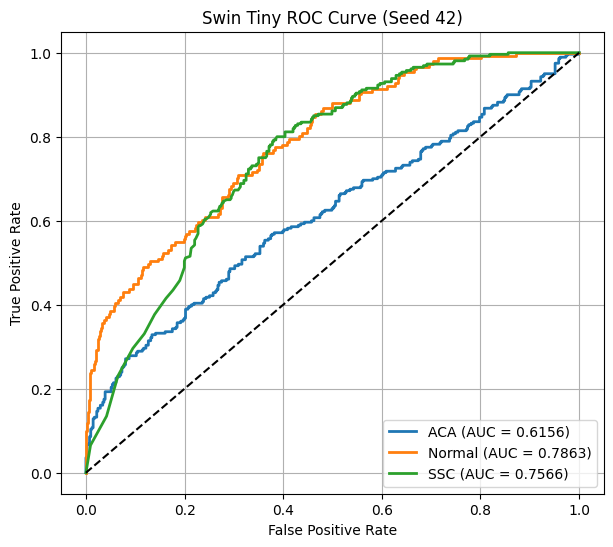

Macro AUC : 0.7195
ACA AUC    : 0.6156
Normal AUC : 0.7863
SSC AUC    : 0.7566
Seed 123
True label distribution
(array([0, 1, 2]), array([280, 151, 260]))

Predicted label distribution
(array([0, 1, 2]), array([153,  21, 517]))

Confusion Matrix
[[ 90   1 189]
 [ 45  20  86]
 [ 18   0 242]]

Per-Class Metrics
------------------------------------------------------------

ACA
Precision : 0.5882
Recall    : 0.3214
F1-score  : 0.4157
Support   : 280

Normal
Precision : 0.9524
Recall    : 0.1325
F1-score  : 0.2326
Support   : 151

SSC
Precision : 0.4681
Recall    : 0.9308
F1-score  : 0.6229
Support   : 260


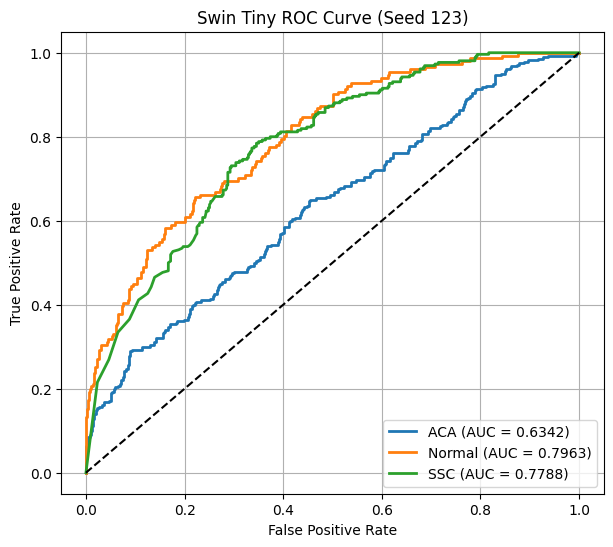

Macro AUC : 0.7365
ACA AUC    : 0.6342
Normal AUC : 0.7963
SSC AUC    : 0.7788
Seed 999
True label distribution
(array([0, 1, 2]), array([280, 151, 260]))

Predicted label distribution
(array([0, 1, 2]), array([168,  16, 507]))

Confusion Matrix
[[ 93   1 186]
 [ 55  15  81]
 [ 20   0 240]]

Per-Class Metrics
------------------------------------------------------------

ACA
Precision : 0.5536
Recall    : 0.3321
F1-score  : 0.4152
Support   : 280

Normal
Precision : 0.9375
Recall    : 0.0993
F1-score  : 0.1796
Support   : 151

SSC
Precision : 0.4734
Recall    : 0.9231
F1-score  : 0.6258
Support   : 260


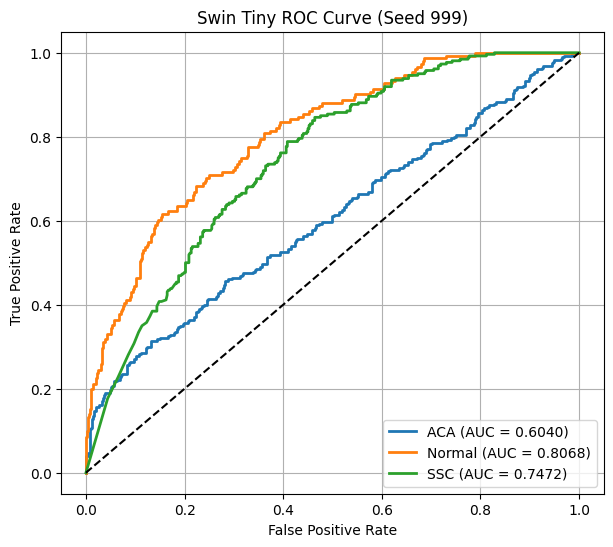

Macro AUC : 0.7193
ACA AUC    : 0.6040
Normal AUC : 0.8068
SSC AUC    : 0.7472
Seed 2025
True label distribution
(array([0, 1, 2]), array([280, 151, 260]))

Predicted label distribution
(array([0, 1, 2]), array([182,  18, 491]))

Confusion Matrix
[[111   1 168]
 [ 47  17  87]
 [ 24   0 236]]

Per-Class Metrics
------------------------------------------------------------

ACA
Precision : 0.6099
Recall    : 0.3964
F1-score  : 0.4805
Support   : 280

Normal
Precision : 0.9444
Recall    : 0.1126
F1-score  : 0.2012
Support   : 151

SSC
Precision : 0.4807
Recall    : 0.9077
F1-score  : 0.6285
Support   : 260


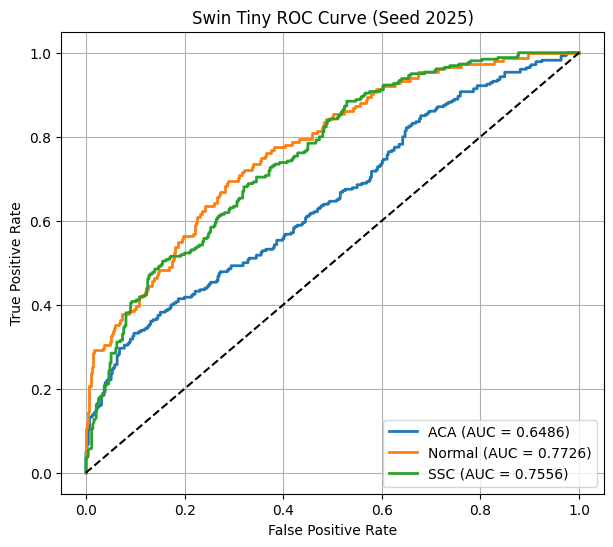

Macro AUC : 0.7256
ACA AUC    : 0.6486
Normal AUC : 0.7726
SSC AUC    : 0.7556
Seed 777
True label distribution
(array([0, 1, 2]), array([280, 151, 260]))

Predicted label distribution
(array([0, 1, 2]), array([153,  15, 523]))

Confusion Matrix
[[ 86   2 192]
 [ 49  13  89]
 [ 18   0 242]]

Per-Class Metrics
------------------------------------------------------------

ACA
Precision : 0.5621
Recall    : 0.3071
F1-score  : 0.3972
Support   : 280

Normal
Precision : 0.8667
Recall    : 0.0861
F1-score  : 0.1566
Support   : 151

SSC
Precision : 0.4627
Recall    : 0.9308
F1-score  : 0.6181
Support   : 260


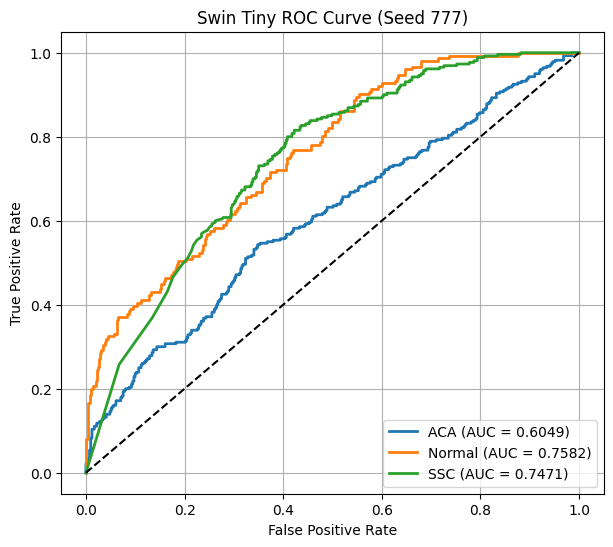

Macro AUC : 0.7034
ACA AUC    : 0.6049
Normal AUC : 0.7582
SSC AUC    : 0.7471


In [50]:
from torchvision.models import swin_t, Swin_T_Weights

SEEDS = [42,123,999,2025,777]

results = []

class_names = ["ACA","Normal","SSC"]

for seed in SEEDS:

    print("="*70)
    print(f"Seed {seed}")
    print("="*70)

    weights = Swin_T_Weights.DEFAULT

    model = swin_t(weights=weights)

    num_features = model.head.in_features
    model.head = nn.Linear(num_features,3)

    model.load_state_dict(
        torch.load(
            f"best_swin_tiny_seed_{seed}.pth",
            map_location=device
        )
    )

    model = model.to(device)
    model.eval()

    acc, bal_acc, prec, rec, f1, mcc, kappa, cm, report = evaluate(
        model,
        external_loader
    )

    macro_auc, class_auc = plot_multiclass_roc(
        model,
        external_loader,
        class_names,
        seed
    )

    print(f"Macro AUC : {macro_auc:.4f}")
    print(f"ACA AUC    : {class_auc[0]:.4f}")
    print(f"Normal AUC : {class_auc[1]:.4f}")
    print(f"SSC AUC    : {class_auc[2]:.4f}")

    results.append({
        "Seed": seed,
        "Accuracy": acc*100,
        "Balanced Accuracy": bal_acc*100,
        "Precision": prec*100,
        "Recall": rec*100,
        "F1-score": f1*100,
        "MCC": mcc,
        "Kappa": kappa,
        "ACA AUC": class_auc[0],
        "Normal AUC": class_auc[1],
        "SSC AUC": class_auc[2],
        "Macro AUC": macro_auc
    })

In [48]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    matthews_corrcoef,
    cohen_kappa_score
)

def evaluate(model, loader):

    model.eval()

    y_true = []
    y_pred = []
    y_prob = []

    with torch.no_grad():

        for images, labels in tqdm(loader):

            images = images.to(device)

            outputs = model(images)

            probs = torch.softmax(outputs, dim=1)

            preds = torch.argmax(outputs, 1)

            y_true.extend(labels.numpy())

            y_pred.extend(preds.cpu().numpy())

            y_prob.extend(probs.cpu().numpy())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_prob = np.array(y_prob)

    acc = accuracy_score(y_true, y_pred)

    bal_acc = balanced_accuracy_score(
        y_true,
        y_pred
    )

    precision = precision_score(
        y_true,
        y_pred,
        average="weighted"
    )

    recall = recall_score(
        y_true,
        y_pred,
        average="weighted"
    )

    f1 = f1_score(
        y_true,
        y_pred,
        average="weighted"
    )

    mcc = matthews_corrcoef(
        y_true,
        y_pred
    )

    kappa = cohen_kappa_score(
        y_true,
        y_pred
    )

    # Print metrics
    print(f"\nAccuracy : {acc:.4f}")
    print(f"Balanced Accuracy : {bal_acc:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall : {recall:.4f}")
    print(f"F1-score : {f1:.4f}")
    print(f"MCC : {mcc:.4f}")
    print(f"Cohen's Kappa : {kappa:.4f}")

    print("\nClassification Report\n")
    print(classification_report(y_true, y_pred))

    return y_true, y_pred, y_prob

In [49]:
print("="*60)
print("LC25000 TEST")
print("="*60)

y_true_lc,\
y_pred_lc,\
y_prob_lc = evaluate(
    model,
    test_loader
)

LC25000 TEST


  0%|          | 0/71 [00:00<?, ?it/s]


Accuracy : 0.9991
Balanced Accuracy : 0.9991
Precision : 0.9991
Recall : 0.9991
F1-score : 0.9991
MCC : 0.9987
Cohen's Kappa : 0.9987

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       734
           1       1.00      1.00      1.00       728
           2       1.00      1.00      1.00       788

    accuracy                           1.00      2250
   macro avg       1.00      1.00      1.00      2250
weighted avg       1.00      1.00      1.00      2250



In [50]:
print("="*60)
print("LUNGHIST700 EXTERNAL TEST")
print("="*60)

y_true_ext,\
y_pred_ext,\
y_prob_ext = evaluate(
    model,
    lunghist_loader
)

LUNGHIST700 EXTERNAL TEST


  0%|          | 0/22 [00:00<?, ?it/s]


Accuracy : 0.5181
Balanced Accuracy : 0.4627
Precision : 0.6418
Recall : 0.5181
F1-score : 0.4576
MCC : 0.2721
Cohen's Kappa : 0.2226

Classification Report

              precision    recall  f1-score   support

           0       0.60      0.36      0.45       280
           1       1.00      0.09      0.17       151
           2       0.48      0.93      0.63       260

    accuracy                           0.52       691
   macro avg       0.69      0.46      0.42       691
weighted avg       0.64      0.52      0.46       691



**CONVNEXT SWIN CONCAT**

In [2]:
SEEDS = [42, 123, 999, 2025, 777]

def set_seed(seed):

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [3]:
LC25000_PATH = "/kaggle/input/datasets/rm1000/lung-cancer-histopathological-images"

LUNGHIST700_PATH = "/kaggle/input/datasets/abdullahhasansajjad/lunghist700"

In [12]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [13]:
from torchvision.datasets import ImageFolder
from torch.utils.data import random_split

# ---------------------------------
# LC25000 Dataset
# ---------------------------------

lc_dataset = ImageFolder(
    root=LC25000_PATH,
    transform=train_transform
)

print("Classes :", lc_dataset.classes)
print("Class mapping :", lc_dataset.class_to_idx)
print("Total Images :", len(lc_dataset))

Classes : ['adenocarcinoma', 'benign', 'squamous_cell_carcinoma']
Class mapping : {'adenocarcinoma': 0, 'benign': 1, 'squamous_cell_carcinoma': 2}
Total Images : 15000


In [14]:
lunghist_dataset = ImageFolder(
    root="/kaggle/input/datasets/abdullahhasansajjad/lunghist700/LungHist700_combined/data/images",
    transform=test_transform
)

print(lunghist_dataset.classes)
print(lunghist_dataset.class_to_idx)
print("Total Images :", len(lunghist_dataset))

['aca', 'nor', 'ssc']
{'aca': 0, 'nor': 1, 'ssc': 2}
Total Images : 691


In [15]:
lunghist_dataset = ImageFolder(
    root="/kaggle/input/datasets/abdullahhasansajjad/lunghist700/LungHist700_combined/data/images",
    transform=test_transform
)

print(lunghist_dataset.classes)
print(lunghist_dataset.class_to_idx)
print("Total Images :", len(lunghist_dataset))

['aca', 'nor', 'ssc']
{'aca': 0, 'nor': 1, 'ssc': 2}
Total Images : 691


In [16]:
from torch.utils.data import Dataset

class LungHist700Dataset(Dataset):

    def __init__(self, dataset):

        self.dataset = dataset

        self.mapping = {
            dataset.class_to_idx['aca']:0,
            dataset.class_to_idx['nor']:1,
            dataset.class_to_idx['ssc']:2
        }

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):

        image,label = self.dataset[idx]

        label = self.mapping[label]

        return image,label


lunghist_dataset = LungHist700Dataset(lunghist_dataset)

In [17]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

lunghist_loader = DataLoader(
    lunghist_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [18]:
import torch
import torch.nn as nn

from torchvision.models import (
    convnext_tiny,
    ConvNeXt_Tiny_Weights,
    swin_t,
    Swin_T_Weights
)


class ConvNeXtSwinConcat(nn.Module):

    def __init__(self, num_classes=3):

        super().__init__()

        # Backbone
        self.convnext = convnext_tiny(
            weights=ConvNeXt_Tiny_Weights.DEFAULT
        )

        self.swin = swin_t(
            weights=Swin_T_Weights.DEFAULT
        )

        # Remove classification heads
        self.convnext.classifier = nn.Identity()
        self.swin.head = nn.Identity()

        # 768 (ConvNeXt) + 768 (Swin)
        self.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(768 + 768, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):

        # ConvNeXt -> (B,768,1,1)
        feat_conv = self.convnext(x)
        feat_conv = torch.flatten(feat_conv, 1)   # (B,768)

        # Swin -> (B,768)
        feat_swin = self.swin(x)

        # Concatenate
        fused = torch.cat([feat_conv, feat_swin], dim=1)

        out = self.classifier(fused)

        return out

In [19]:
model = ConvNeXtSwinConcat(num_classes=3)

model = model.to(device)

Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 181MB/s]  


Downloading: "https://download.pytorch.org/models/swin_t-704ceda3.pth" to /root/.cache/torch/hub/checkpoints/swin_t-704ceda3.pth


100%|██████████| 108M/108M [00:00<00:00, 180MB/s]  


In [20]:
torch.save(
    model.state_dict(),
    "best_convnext_swin_concat.pth"
)

In [21]:
model = ConvNeXtSwinConcat(num_classes=3)

model.load_state_dict(
    torch.load(
        "best_convnext_swin_concat.pth",
        map_location=device
    )
)

model = model.to(device)

model.eval()

ConvNeXtSwinConcat(
  (convnext): ConvNeXt(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
        (1): LayerNorm2d((96,), eps=1e-06, elementwise_affine=True)
      )
      (1): Sequential(
        (0): CNBlock(
          (block): Sequential(
            (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
            (1): Permute()
            (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
            (3): Linear(in_features=96, out_features=384, bias=True)
            (4): GELU(approximate='none')
            (5): Linear(in_features=384, out_features=96, bias=True)
            (6): Permute()
          )
          (stochastic_depth): StochasticDepth(p=0.0, mode=row)
        )
        (1): CNBlock(
          (block): Sequential(
            (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
            (1): Permute()
            (2): LayerNo

In [22]:
criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler = CosineAnnealingLR(
    optimizer,
    T_max=20
)

scaler = torch.cuda.amp.GradScaler()

In [23]:
class EarlyStopping:

    def __init__(self, patience=7):

        self.patience = patience

        self.counter = 0

        self.best_loss = np.inf

        self.stop = False

    def __call__(self, val_loss):

        if val_loss < self.best_loss:

            self.best_loss = val_loss

            self.counter = 0

        else:

            self.counter += 1

            if self.counter >= self.patience:

                self.stop = True


early_stop = EarlyStopping(patience=7)

In [24]:
def train_one_epoch(model, loader):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    loop = tqdm(loader)

    for images, labels in loop:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast():

            outputs = model(images)

            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()

        scaler.step(optimizer)

        scaler.update()

        running_loss += loss.item()

        _, preds = torch.max(outputs,1)

        correct += (preds==labels).sum().item()

        total += labels.size(0)

        loop.set_postfix(
            loss=loss.item(),
            acc=100*correct/total
        )

    epoch_loss = running_loss/len(loader)

    epoch_acc = correct/total

    return epoch_loss, epoch_acc

In [25]:
def validate(model, loader):

    model.eval()

    running_loss = 0

    correct = 0

    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)

            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, preds = torch.max(outputs,1)

            correct += (preds==labels).sum().item()

            total += labels.size(0)

    epoch_loss = running_loss/len(loader)

    epoch_acc = correct/total

    return epoch_loss, epoch_acc

In [26]:
NUM_EPOCHS = 10
SEEDS = [42, 123, 999, 2025, 777]

all_best_acc = []

for seed in SEEDS:

    print("\n" + "="*60)
    print(f"Training with Seed = {seed}")
    print("="*60)

    # -------------------------
    # Set Seed
    # -------------------------
    set_seed(seed)

    # -------------------------
    # Dataset Split
    # -------------------------
    train_dataset, val_dataset, test_dataset = random_split(
        lc_dataset,
        [train_size, val_size, test_size],
        generator=torch.Generator().manual_seed(seed)
    )

    val_dataset.dataset.transform = test_transform
    test_dataset.dataset.transform = test_transform

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False
    )

    # -------------------------
    # Model
    # -------------------------
    model = ConvNeXtSwinConcat(num_classes=3)
    model = model.to(device)

    # -------------------------
    # Optimizer
    # -------------------------
    optimizer = optim.AdamW(
        model.parameters(),
        lr=1e-4,
        weight_decay=1e-4
    )

    # -------------------------
    # Scheduler
    # -------------------------
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=NUM_EPOCHS
    )

    # -------------------------
    # Early Stopping
    # -------------------------
    early_stop = EarlyStopping(patience=5)

    best_acc = 0

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    # -------------------------
    # Training Loop
    # -------------------------
    for epoch in range(NUM_EPOCHS):

        print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")

        train_loss, train_acc = train_one_epoch(
            model,
            train_loader
        )

        val_loss, val_acc = validate(
            model,
            val_loader
        )

        scheduler.step()

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(f"Train Loss : {train_loss:.4f}")
        print(f"Train Acc  : {train_acc*100:.2f}%")
        print(f"Val Loss   : {val_loss:.4f}")
        print(f"Val Acc    : {val_acc*100:.2f}%")

        if val_acc > best_acc:

            best_acc = val_acc

            torch.save(
                model.state_dict(),
                f"best_convnext_swin_concat_seed_{seed}.pth"
            )

            print("Model Saved.")

        early_stop(val_loss)

        if early_stop.stop:
            print("Early stopping...")
            break

    print(f"\nBest Validation Accuracy (Seed {seed}) = {best_acc*100:.2f}%")

    all_best_acc.append(best_acc)

print("\n" + "="*60)
print("Training Finished")
print("="*60)

print("Validation Accuracies:")
for seed, acc in zip(SEEDS, all_best_acc):
    print(f"Seed {seed}: {acc*100:.2f}%")

print(f"\nMean Validation Accuracy = {np.mean(all_best_acc)*100:.2f}%")
print(f"Std  Validation Accuracy = {np.std(all_best_acc)*100:.2f}%")


Training with Seed = 42

Epoch 1/10


  0%|          | 0/329 [00:00<?, ?it/s]

Train Loss : 0.1208
Train Acc  : 95.66%
Val Loss   : 0.0123
Val Acc    : 99.64%
Model Saved.

Epoch 2/10


  0%|          | 0/329 [00:00<?, ?it/s]

Train Loss : 0.0313
Train Acc  : 98.97%
Val Loss   : 0.0067
Val Acc    : 99.87%
Model Saved.

Epoch 3/10


...

Train Loss : 0.0001
Train Acc  : 100.00%
Val Loss   : 0.0011
Val Acc    : 99.96%

Epoch 9/10


  0%|          | 0/329 [00:00<?, ?it/s]

Train Loss : 0.0006
Train Acc  : 99.99%
Val Loss   : 0.0008
Val Acc    : 99.96%

Epoch 10/10


  0%|          | 0/329 [00:00<?, ?it/s]

Train Loss : 0.0001
Train Acc  : 100.00%
Val Loss   : 0.0011
Val Acc    : 99.96%

Best Validation Accuracy (Seed 777) = 100.00%

Training Finished
Validation Accuracies:
Seed 42: 100.00%
Seed 123: 99.91%
Seed 999: 99.91%
Seed 2025: 100.00%
Seed 777: 100.00%

Mean Validation Accuracy = 99.96%
Std  Validation Accuracy = 0.04%


In [27]:
model = ConvNeXtSwinConcat(num_classes=3)

model.load_state_dict(
    torch.load(
        "best_convnext_swin_concat.pth",
        map_location=device
    )
)

model = model.to(device)

model.eval()

ConvNeXtSwinConcat(
  (convnext): ConvNeXt(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
        (1): LayerNorm2d((96,), eps=1e-06, elementwise_affine=True)
      )
      (1): Sequential(
        (0): CNBlock(
          (block): Sequential(
            (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
            (1): Permute()
            (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
            (3): Linear(in_features=96, out_features=384, bias=True)
            (4): GELU(approximate='none')
            (5): Linear(in_features=384, out_features=96, bias=True)
            (6): Permute()
          )
          (stochastic_depth): StochasticDepth(p=0.0, mode=row)
        )
        (1): CNBlock(
          (block): Sequential(
            (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
            (1): Permute()
            (2): LayerNo

In [28]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("abdullahhasansajjad/lunghist700")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/abdullahhasansajjad/lunghist700


In [29]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rm1000/lung-cancer-histopathological-images")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/rm1000/lung-cancer-histopathological-images


In [30]:
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

LUNGHIST700_PATH = "/kaggle/input/datasets/abdullahhasansajjad/lunghist700/LungHist700_combined/data/images"

external_dataset = ImageFolder(
    root=LUNGHIST700_PATH,
    transform=test_transform
)

print(external_dataset.class_to_idx)
print("Images:", len(external_dataset))

external_loader = DataLoader(
    external_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

{'aca': 0, 'nor': 1, 'ssc': 2}
Images: 691


In [31]:
from sklearn.metrics import classification_report

In [32]:
import numpy as np
import torch

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    cohen_kappa_score,
    confusion_matrix
)

def evaluate(model, loader):

    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)

            outputs = model(images)

            preds = torch.argmax(outputs, dim=1)

            y_true.extend(labels.numpy().tolist())
            y_pred.extend(preds.cpu().numpy().tolist())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # ---------------- Debug ----------------
    print("="*60)
    print("True label distribution")
    print(np.unique(y_true, return_counts=True))

    print("\nPredicted label distribution")
    print(np.unique(y_pred, return_counts=True))

    print("\nConfusion Matrix")
    cm = confusion_matrix(y_true, y_pred)
    print(cm)
    print("="*60)

    # ---------------- Metrics ----------------
    acc = accuracy_score(y_true, y_pred)

    bal_acc = balanced_accuracy_score(
        y_true,
        y_pred
    )

    precision = precision_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    mcc = matthews_corrcoef(
        y_true,
        y_pred
    )

    kappa = cohen_kappa_score(
        y_true,
        y_pred
    )

    return (
        acc,
        bal_acc,
        precision,
        recall,
        f1,
        mcc,
        kappa,
        cm
    )
    

In [33]:
import numpy as np
import torch

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    cohen_kappa_score,
    confusion_matrix,
    classification_report
)

def evaluate(model, loader):

    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)

            outputs = model(images)

            preds = torch.argmax(outputs, dim=1)

            y_true.extend(labels.numpy().tolist())
            y_pred.extend(preds.cpu().numpy().tolist())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # ---------------- Debug ----------------
    print("="*60)
    print("True label distribution")
    print(np.unique(y_true, return_counts=True))

    print("\nPredicted label distribution")
    print(np.unique(y_pred, return_counts=True))

    print("\nConfusion Matrix")
    cm = confusion_matrix(y_true, y_pred)
    print(cm)

    # ---------------- Overall Metrics ----------------
    acc = accuracy_score(y_true, y_pred)

    bal_acc = balanced_accuracy_score(
        y_true,
        y_pred
    )

    precision = precision_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    mcc = matthews_corrcoef(
        y_true,
        y_pred
    )

    kappa = cohen_kappa_score(
        y_true,
        y_pred
    )

    # ---------------- Per-Class Metrics ----------------
    class_names = ["ACA", "Normal", "SSC"]

    report = classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        output_dict=True,
        zero_division=0
    )

    print("\nPer-Class Metrics")
    print("-"*60)

    for cls in class_names:

        print(f"\n{cls}")
        print(f"Precision : {report[cls]['precision']:.4f}")
        print(f"Recall    : {report[cls]['recall']:.4f}")
        print(f"F1-score  : {report[cls]['f1-score']:.4f}")
        print(f"Support   : {int(report[cls]['support'])}")

    print("="*60)

    return (
        acc,
        bal_acc,
        precision,
        recall,
        f1,
        mcc,
        kappa,
        cm,
        report
    )

In [35]:
import pandas as pd

SEEDS = [42, 123, 999, 2025, 777]

results = []
per_class_results = []

for seed in SEEDS:

    print("=" * 70)
    print(f"Evaluating Seed {seed}")
    print("=" * 70)

    # -------------------------
    # Model
    # -------------------------
    model = ConvNeXtSwinConcat(num_classes=3)

    # -------------------------
    # Load trained weights
    # -------------------------
    model.load_state_dict(
        torch.load(
            f"best_convnext_swin_concat_seed_{seed}.pth",
            map_location=device
        )
    )

    model = model.to(device)
    model.eval()

    # -------------------------
    # Evaluation
    # -------------------------
    acc, bal_acc, prec, rec, f1, mcc, kappa, cm, report = evaluate(
        model,
        external_loader
    )

    print(f"Accuracy           : {acc*100:.2f}%")
    print(f"Balanced Accuracy  : {bal_acc*100:.2f}%")
    print(f"Precision          : {prec*100:.2f}%")
    print(f"Recall             : {rec*100:.2f}%")
    print(f"F1-score           : {f1*100:.2f}%")
    print(f"MCC                : {mcc:.4f}")
    print(f"Kappa              : {kappa:.4f}")

    # -------------------------
    # Overall metrics
    # -------------------------
    results.append({
        "Seed": seed,
        "Accuracy": acc * 100,
        "Balanced Accuracy": bal_acc * 100,
        "Precision": prec * 100,
        "Recall": rec * 100,
        "F1-score": f1 * 100,
        "MCC": mcc,
        "Kappa": kappa
    })

    # -------------------------
    # Per-class metrics
    # -------------------------
    for cls in ["ACA", "Normal", "SSC"]:

        per_class_results.append({
            "Seed": seed,
            "Class": cls,
            "Precision": report[cls]["precision"] * 100,
            "Recall": report[cls]["recall"] * 100,
            "F1-score": report[cls]["f1-score"] * 100,
            "Support": int(report[cls]["support"])
        })

# -------------------------
# DataFrames
# -------------------------
results_df = pd.DataFrame(results)
per_class_df = pd.DataFrame(per_class_results)

print("\nOverall Results")
display(results_df)

print("\nPer-Class Results")
display(per_class_df)

Evaluating Seed 42
True label distribution
(array([0, 1, 2]), array([280, 151, 260]))

Predicted label distribution
(array([0, 1, 2]), array([207,  16, 468]))

Confusion Matrix
[[118   0 162]
 [ 63  16  72]
 [ 26   0 234]]

Per-Class Metrics
------------------------------------------------------------

ACA
Precision : 0.5700
Recall    : 0.4214
F1-score  : 0.4846
Support   : 280

Normal
Precision : 1.0000
Recall    : 0.1060
F1-score  : 0.1916
Support   : 151

SSC
Precision : 0.5000
Recall    : 0.9000
F1-score  : 0.6429
Support   : 260
Accuracy           : 53.26%
Balanced Accuracy  : 47.58%
Precision          : 63.76%
Recall             : 53.26%
F1-score           : 48.01%
MCC                : 0.2802
Kappa              : 0.2445
Evaluating Seed 123
True label distribution
(array([0, 1, 2]), array([280, 151, 260]))

Predicted label distribution
(array([0, 1, 2]), array([122,  34, 535]))

Confusion Matrix
[[ 78   5 197]
 [ 36  29  86]
 [  8   0 252]]

Per-Class Metrics
---------------------

,Seed,Accuracy,Balanced Accuracy,Precision,Recall,F1-score,MCC,Kappa
0,42,53.256151,47.579628,63.764620,53.256151,48.012283,0.280157,0.244502
1,123,51.953690,47.995173,62.268857,51.953690,46.429442,0.299596,0.232959
2,999,52.821997,47.092339,60.977205,52.821997,46.889556,0.278690,0.238259
3,2025,50.072359,44.988053,60.621752,50.072359,44.269122,0.237337,0.195465
4,777,50.940666,45.618951,61.163893,50.940666,45.045941,0.250931,0.208792



Per-Class Results


,Seed,Class,Precision,Recall,F1-score,Support
0,42,ACA,57.004831,42.142857,48.459959,280
1,42,Normal,100.000000,10.596026,19.161677,151
2,42,SSC,50.000000,90.000000,64.285714,260
3,123,ACA,63.934426,27.857143,38.805970,280
4,123,Normal,85.294118,19.205298,31.351351,151
5,123,SSC,47.102804,96.923077,63.396226,260
6,999,ACA,56.770833,38.928571,46.186441,280
7,999,Normal,87.500000,9.271523,16.766467,151
8,999,SSC,50.103520,93.076923,65.141319,260
9,2025,ACA,55.357143,33.214286,41.517857,280


In [36]:
import pandas as pd

# ==========================================================
# OVERALL RESULTS
# ==========================================================

results_df = pd.DataFrame(results)

print("\n==================== PER-SEED RESULTS ====================\n")
print(results_df.round(2))

metrics = [
    "Accuracy",
    "Balanced Accuracy",
    "Precision",
    "Recall",
    "F1-score",
    "MCC",
    "Kappa"
]

summary = pd.DataFrame({
    "Metric": metrics,
    "Mean": [results_df[m].mean() for m in metrics],
    "SD": [results_df[m].std(ddof=1) for m in metrics]
})

summary["Mean ± SD"] = summary.apply(
    lambda x: f"{x['Mean']:.2f} ± {x['SD']:.2f}",
    axis=1
)

print("\n==================== OVERALL MEAN ± SD ====================\n")
print(summary[["Metric", "Mean ± SD"]])

# Save overall results
results_df.to_csv("LungHist700_5Seed_Results.csv", index=False)
summary.to_csv("LungHist700_Mean_SD.csv", index=False)


# ==========================================================
# PER-CLASS RESULTS
# ==========================================================

if len(per_class_results) > 0:

    per_class_df = pd.DataFrame(per_class_results)

    print("\n==================== PER-CLASS RESULTS ====================\n")
    print(per_class_df.round(2))

    rows = []

    for cls in ["ACA", "Normal", "SSC"]:

        temp = per_class_df[per_class_df["Class"] == cls]

        rows.append({
            "Class": cls,
            "Precision": f"{temp['Precision'].mean():.2f} ± {temp['Precision'].std(ddof=1):.2f}",
            "Recall": f"{temp['Recall'].mean():.2f} ± {temp['Recall'].std(ddof=1):.2f}",
            "F1-score": f"{temp['F1-score'].mean():.2f} ± {temp['F1-score'].std(ddof=1):.2f}",
        })

    per_class_summary = pd.DataFrame(rows)

    print("\n==================== PER-CLASS MEAN ± SD ====================\n")
    print(per_class_summary)

    per_class_df.to_csv("Per_Class_Results.csv", index=False)
    per_class_summary.to_csv("Per_Class_Mean_SD.csv", index=False)

else:
    print("\nper_class_results is empty.")
    print("You need to populate it inside the evaluation loop.")


==================== PER-SEED RESULTS ====================

   Seed  Accuracy  Balanced Accuracy  Precision  Recall  F1-score   MCC  Kappa
0    42     53.26              47.58      63.76   53.26     48.01  0.28   0.24
1   123     51.95              48.00      62.27   51.95     46.43  0.30   0.23
2   999     52.82              47.09      60.98   52.82     46.89  0.28   0.24
3  2025     50.07              44.99      60.62   50.07     44.27  0.24   0.20
4   777     50.94              45.62      61.16   50.94     45.05  0.25   0.21

==================== OVERALL MEAN ± SD ====================

              Metric     Mean ± SD
0           Accuracy  51.81 ± 1.31
1  Balanced Accuracy  46.65 ± 1.29
2          Precision  61.76 ± 1.28
3             Recall  51.81 ± 1.31
4           F1-score  46.13 ± 1.49
5                MCC   0.27 ± 0.02
6              Kappa   0.22 ± 0.02

==================== PER-CLASS RESULTS ====================

    Seed   Class  Precision  Recall  F1-score  Support
0     

In [38]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import torch
import numpy as np

def plot_multiclass_roc(model, dataloader, class_names, seed):

    model.eval()

    y_true = []
    y_score = []

    with torch.no_grad():

        for images, labels in dataloader:

            images = images.to(device)

            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)

            y_score.extend(probs.cpu().numpy())
            y_true.extend(labels.numpy())

    y_true = np.array(y_true)
    y_score = np.array(y_score)

    n_classes = len(class_names)

    y_true_bin = label_binarize(
        y_true,
        classes=np.arange(n_classes)
    )

    fpr = {}
    tpr = {}
    roc_auc = {}

    plt.figure(figsize=(7,6))

    for i in range(n_classes):

        fpr[i], tpr[i], _ = roc_curve(
            y_true_bin[:, i],
            y_score[:, i]
        )

        roc_auc[i] = auc(fpr[i], tpr[i])

        plt.plot(
            fpr[i],
            tpr[i],
            lw=2,
            label=f"{class_names[i]} (AUC = {roc_auc[i]:.4f})"
        )

    macro_auc = np.mean(list(roc_auc.values()))

    plt.plot([0,1],[0,1],'k--')

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f" Convnext_Swin_Concatenate ROC Curve (Seed {seed})")
    plt.legend(loc="lower right")
    plt.grid(True)

    plt.show()

    return macro_auc, roc_auc

Seed 42
True label distribution
(array([0, 1, 2]), array([280, 151, 260]))

Predicted label distribution
(array([0, 1, 2]), array([207,  16, 468]))

Confusion Matrix
[[118   0 162]
 [ 63  16  72]
 [ 26   0 234]]

Per-Class Metrics
------------------------------------------------------------

ACA
Precision : 0.5700
Recall    : 0.4214
F1-score  : 0.4846
Support   : 280

Normal
Precision : 1.0000
Recall    : 0.1060
F1-score  : 0.1916
Support   : 151

SSC
Precision : 0.5000
Recall    : 0.9000
F1-score  : 0.6429
Support   : 260


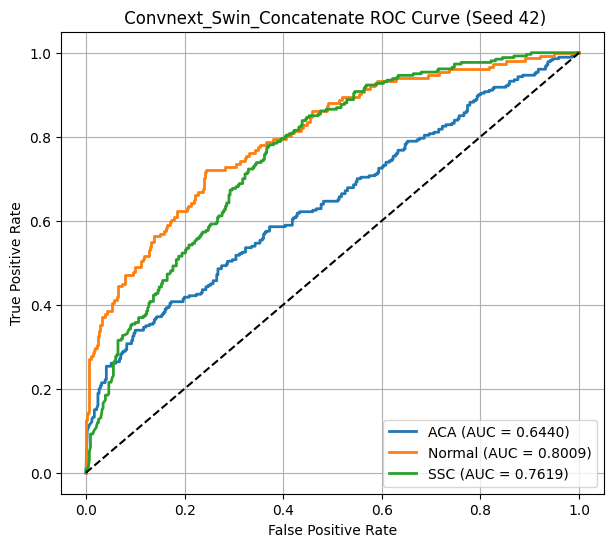

Accuracy           : 53.26%
Balanced Accuracy  : 47.58%
Precision          : 63.76%
Recall             : 53.26%
F1-score           : 48.01%
MCC                : 0.2802
Kappa              : 0.2445
Macro AUC          : 0.7356
ACA AUC            : 0.6440
Normal AUC         : 0.8009
SSC AUC            : 0.7619
Seed 123
True label distribution
(array([0, 1, 2]), array([280, 151, 260]))

Predicted label distribution
(array([0, 1, 2]), array([122,  34, 535]))

Confusion Matrix
[[ 78   5 197]
 [ 36  29  86]
 [  8   0 252]]

Per-Class Metrics
------------------------------------------------------------

ACA
Precision : 0.6393
Recall    : 0.2786
F1-score  : 0.3881
Support   : 280

Normal
Precision : 0.8529
Recall    : 0.1921
F1-score  : 0.3135
Support   : 151

SSC
Precision : 0.4710
Recall    : 0.9692
F1-score  : 0.6340
Support   : 260


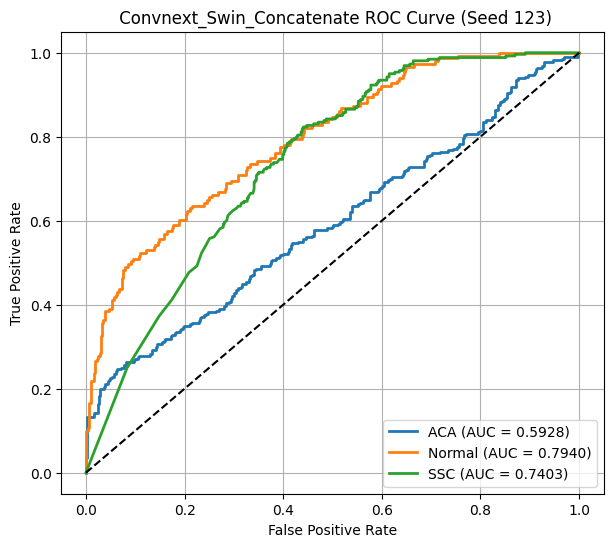

Accuracy           : 51.95%
Balanced Accuracy  : 48.00%
Precision          : 62.27%
Recall             : 51.95%
F1-score           : 46.43%
MCC                : 0.2996
Kappa              : 0.2330
Macro AUC          : 0.7090
ACA AUC            : 0.5928
Normal AUC         : 0.7940
SSC AUC            : 0.7403
Seed 999
True label distribution
(array([0, 1, 2]), array([280, 151, 260]))

Predicted label distribution
(array([0, 1, 2]), array([192,  16, 483]))

Confusion Matrix
[[109   2 169]
 [ 65  14  72]
 [ 18   0 242]]

Per-Class Metrics
------------------------------------------------------------

ACA
Precision : 0.5677
Recall    : 0.3893
F1-score  : 0.4619
Support   : 280

Normal
Precision : 0.8750
Recall    : 0.0927
F1-score  : 0.1677
Support   : 151

SSC
Precision : 0.5010
Recall    : 0.9308
F1-score  : 0.6514
Support   : 260


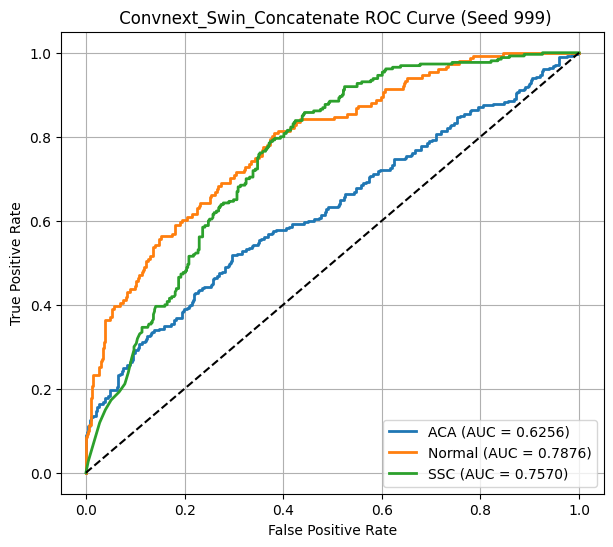

Accuracy           : 52.82%
Balanced Accuracy  : 47.09%
Precision          : 60.98%
Recall             : 52.82%
F1-score           : 46.89%
MCC                : 0.2787
Kappa              : 0.2383
Macro AUC          : 0.7234
ACA AUC            : 0.6256
Normal AUC         : 0.7876
SSC AUC            : 0.7570
Seed 2025
True label distribution
(array([0, 1, 2]), array([280, 151, 260]))

Predicted label distribution
(array([0, 1, 2]), array([168,  17, 506]))

Confusion Matrix
[[ 93   1 186]
 [ 52  16  83]
 [ 23   0 237]]

Per-Class Metrics
------------------------------------------------------------

ACA
Precision : 0.5536
Recall    : 0.3321
F1-score  : 0.4152
Support   : 280

Normal
Precision : 0.9412
Recall    : 0.1060
F1-score  : 0.1905
Support   : 151

SSC
Precision : 0.4684
Recall    : 0.9115
F1-score  : 0.6188
Support   : 260


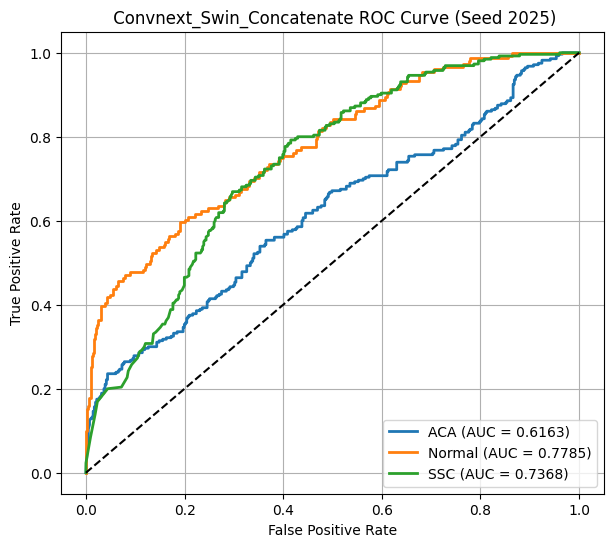

Accuracy           : 50.07%
Balanced Accuracy  : 44.99%
Precision          : 60.62%
Recall             : 50.07%
F1-score           : 44.27%
MCC                : 0.2373
Kappa              : 0.1955
Macro AUC          : 0.7105
ACA AUC            : 0.6163
Normal AUC         : 0.7785
SSC AUC            : 0.7368
Seed 777
True label distribution
(array([0, 1, 2]), array([280, 151, 260]))

Predicted label distribution
(array([0, 1, 2]), array([175,  16, 500]))

Confusion Matrix
[[ 98   1 181]
 [ 56  15  80]
 [ 21   0 239]]

Per-Class Metrics
------------------------------------------------------------

ACA
Precision : 0.5600
Recall    : 0.3500
F1-score  : 0.4308
Support   : 280

Normal
Precision : 0.9375
Recall    : 0.0993
F1-score  : 0.1796
Support   : 151

SSC
Precision : 0.4780
Recall    : 0.9192
F1-score  : 0.6289
Support   : 260


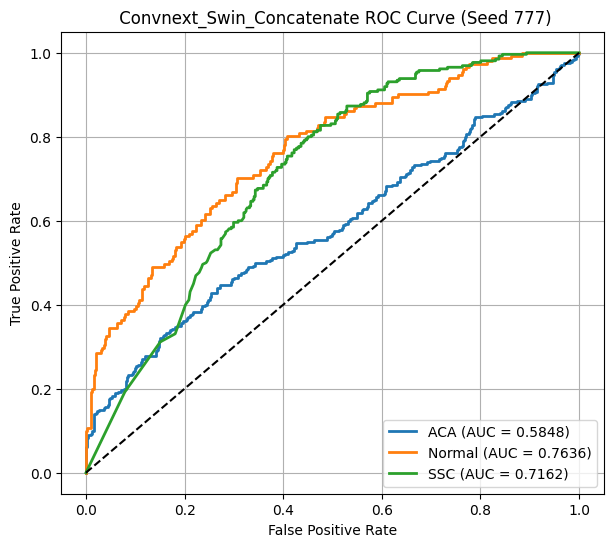

Accuracy           : 50.94%
Balanced Accuracy  : 45.62%
Precision          : 61.16%
Recall             : 50.94%
F1-score           : 45.05%
MCC                : 0.2509
Kappa              : 0.2088
Macro AUC          : 0.6882
ACA AUC            : 0.5848
Normal AUC         : 0.7636
SSC AUC            : 0.7162

Overall Results


,Seed,Accuracy,Balanced Accuracy,Precision,Recall,F1-score,MCC,Kappa,ACA AUC,Normal AUC,SSC AUC,Macro AUC
0,42,53.256151,47.579628,63.764620,53.256151,48.012283,0.280157,0.244502,0.644048,0.800944,0.761895,0.735629
1,123,51.953690,47.995173,62.268857,51.953690,46.429442,0.299596,0.232959,0.592770,0.793966,0.740322,0.709020
2,999,52.821997,47.092339,60.977205,52.821997,46.889556,0.278690,0.238259,0.625617,0.787626,0.756992,0.723411
3,2025,50.072359,44.988053,60.621752,50.072359,44.269122,0.237337,0.195465,0.616310,0.778489,0.736811,0.710537
4,777,50.940666,45.618951,61.163893,50.940666,45.045941,0.250931,0.208792,0.584819,0.763637,0.716223,0.688227



Mean ± SD
Accuracy            : 51.8090 ± 1.3145
Balanced Accuracy   : 46.6548 ± 1.2937
Precision           : 61.7593 ± 1.2788
Recall              : 51.8090 ± 1.3145
F1-score            : 46.1293 ± 1.4872
MCC                 : 0.2693 ± 0.0249
Kappa               : 0.2240 ± 0.0209
ACA AUC             : 0.6127 ± 0.0242
Normal AUC          : 0.7849 ± 0.0145
SSC AUC             : 0.7424 ± 0.0181
Macro AUC           : 0.7134 ± 0.0177


In [39]:
SEEDS = [42, 123, 999, 2025, 777]

results = []

class_names = ["ACA", "Normal", "SSC"]

for seed in SEEDS:

    print("=" * 70)
    print(f"Seed {seed}")
    print("=" * 70)

    # -------------------------
    # Load Model
    # -------------------------
    model = ConvNeXtSwinConcat(num_classes=3)

    model.load_state_dict(
        torch.load(
            f"best_convnext_swin_concat_seed_{seed}.pth",
            map_location=device
        )
    )

    model = model.to(device)
    model.eval()

    # -------------------------
    # Evaluate
    # -------------------------
    acc, bal_acc, prec, rec, f1, mcc, kappa, cm, report = evaluate(
        model,
        external_loader
    )

    # -------------------------
    # ROC-AUC
    # -------------------------
    macro_auc, class_auc = plot_multiclass_roc(
        model,
        external_loader,
        class_names,
        seed
    )

    print(f"Accuracy           : {acc*100:.2f}%")
    print(f"Balanced Accuracy  : {bal_acc*100:.2f}%")
    print(f"Precision          : {prec*100:.2f}%")
    print(f"Recall             : {rec*100:.2f}%")
    print(f"F1-score           : {f1*100:.2f}%")
    print(f"MCC                : {mcc:.4f}")
    print(f"Kappa              : {kappa:.4f}")

    print(f"Macro AUC          : {macro_auc:.4f}")
    print(f"ACA AUC            : {class_auc[0]:.4f}")
    print(f"Normal AUC         : {class_auc[1]:.4f}")
    print(f"SSC AUC            : {class_auc[2]:.4f}")

    results.append({
        "Seed": seed,
        "Accuracy": acc * 100,
        "Balanced Accuracy": bal_acc * 100,
        "Precision": prec * 100,
        "Recall": rec * 100,
        "F1-score": f1 * 100,
        "MCC": mcc,
        "Kappa": kappa,
        "ACA AUC": class_auc[0],
        "Normal AUC": class_auc[1],
        "SSC AUC": class_auc[2],
        "Macro AUC": macro_auc
    })

# -------------------------
# Results Table
# -------------------------
results_df = pd.DataFrame(results)

print("\nOverall Results")
display(results_df)

print("\nMean ± SD")
for col in results_df.columns[1:]:
    print(f"{col:<20}: {results_df[col].mean():.4f} ± {results_df[col].std():.4f}")

In [40]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rm1000/lung-cancer-histopathological-images")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/rm1000/lung-cancer-histopathological-images


In [41]:
LC25000_PATH = "/kaggle/input/datasets/rm1000/lung-cancer-histopathological-images"

lc_dataset = ImageFolder(
    root=LC25000_PATH,
    transform=test_transform
)

In [42]:
from torch.utils.data import random_split, DataLoader
import pandas as pd
import numpy as np

SEEDS = [42, 123, 999, 2025, 777]

internal_results = []

for seed in SEEDS:

    # Same split used during training
    train_dataset, val_dataset, test_dataset = random_split(
        lc_dataset,
        [train_size, val_size, test_size],
        generator=torch.Generator().manual_seed(seed)
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False
    )

    model = ConvNeXtSwinConcat(num_classes=3)

    model.load_state_dict(
        torch.load(
            f"best_convnext_swin_concat_seed_{seed}.pth",
            map_location=device
        )
    )

    model = model.to(device)
    model.eval()

    acc, bal_acc, prec, rec, f1, mcc, kappa, cm, report = evaluate(
        model,
        test_loader
    )

    internal_results.append({
        "Seed": seed,
        "Accuracy": acc * 100,
        "Balanced Accuracy": bal_acc * 100,
        "Precision": prec * 100,
        "Recall": rec * 100,
        "F1-score": f1 * 100,
        "MCC": mcc,
        "Kappa": kappa
    })

internal_results_df = pd.DataFrame(internal_results)

display(internal_results_df)

print("\nMean ± SD on LC25000 Test Set\n")

for col in internal_results_df.columns[1:]:
    print(
        f"{col:<20}: "
        f"{internal_results_df[col].mean():.2f} ± {internal_results_df[col].std():.2f}"
    )

True label distribution
(array([0, 1, 2]), array([734, 728, 788]))

Predicted label distribution
(array([0, 1, 2]), array([734, 728, 788]))

Confusion Matrix
[[734   0   0]
 [  0 728   0]
 [  0   0 788]]

Per-Class Metrics
------------------------------------------------------------

ACA
Precision : 1.0000
Recall    : 1.0000
F1-score  : 1.0000
Support   : 734

Normal
Precision : 1.0000
Recall    : 1.0000
F1-score  : 1.0000
Support   : 728

SSC
Precision : 1.0000
Recall    : 1.0000
F1-score  : 1.0000
Support   : 788
True label distribution
(array([0, 1, 2]), array([732, 745, 773]))

Predicted label distribution
(array([0, 1, 2]), array([731, 745, 774]))

Confusion Matrix
[[731   0   1]
 [  0 745   0]
 [  0   0 773]]

Per-Class Metrics
------------------------------------------------------------

ACA
Precision : 1.0000
Recall    : 0.9986
F1-score  : 0.9993
Support   : 732

Normal
Precision : 1.0000
Recall    : 1.0000
F1-score  : 1.0000
Support   : 745

SSC
Precision : 0.9987
Recall    : 

,Seed,Accuracy,Balanced Accuracy,Precision,Recall,F1-score,MCC,Kappa
0,42,100.000000,100.000000,100.000000,100.000000,100.000000,1.000000,1.000000
1,123,99.955556,99.954463,99.955613,99.955556,99.955555,0.999333,0.999333
2,999,100.000000,100.000000,100.000000,100.000000,100.000000,1.000000,1.000000
3,2025,99.911111,99.910100,99.911111,99.911111,99.911111,0.998666,0.998666
4,777,99.911111,99.910515,99.911348,99.911111,99.911111,0.998668,0.998667



Mean ± SD on LC25000 Test Set

Accuracy            : 99.96 ± 0.04
Balanced Accuracy   : 99.96 ± 0.04
Precision           : 99.96 ± 0.04
Recall              : 99.96 ± 0.04
F1-score            : 99.96 ± 0.04
MCC                 : 1.00 ± 0.00
Kappa               : 1.00 ± 0.00


In [84]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    matthews_corrcoef,
    cohen_kappa_score
)

def evaluate(model, loader):

    model.eval()

    y_true = []
    y_pred = []
    y_prob = []

    with torch.no_grad():

        for images, labels in tqdm(loader):

            images = images.to(device)

            outputs = model(images)

            probs = torch.softmax(outputs, dim=1)

            preds = torch.argmax(outputs, 1)

            y_true.extend(labels.numpy())

            y_pred.extend(preds.cpu().numpy())

            y_prob.extend(probs.cpu().numpy())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_prob = np.array(y_prob)

    acc = accuracy_score(y_true, y_pred)

    bal_acc = balanced_accuracy_score(
        y_true,
        y_pred
    )

    precision = precision_score(
        y_true,
        y_pred,
        average="weighted"
    )

    recall = recall_score(
        y_true,
        y_pred,
        average="weighted"
    )

    f1 = f1_score(
        y_true,
        y_pred,
        average="weighted"
    )

    mcc = matthews_corrcoef(
        y_true,
        y_pred
    )

    kappa = cohen_kappa_score(
        y_true,
        y_pred
    )

    # Print metrics
    print(f"\nAccuracy : {acc:.4f}")
    print(f"Balanced Accuracy : {bal_acc:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall : {recall:.4f}")
    print(f"F1-score : {f1:.4f}")
    print(f"MCC : {mcc:.4f}")
    print(f"Cohen's Kappa : {kappa:.4f}")

    print("\nClassification Report\n")
    print(classification_report(y_true, y_pred))

    return y_true, y_pred, y_prob

In [85]:
print("="*60)
print("LC25000 TEST")
print("="*60)

y_true_lc,\
y_pred_lc,\
y_prob_lc = evaluate(
    model,
    test_loader
)

LC25000 TEST


  0%|          | 0/71 [00:00<?, ?it/s]


Accuracy : 1.0000
Balanced Accuracy : 1.0000
Precision : 1.0000
Recall : 1.0000
F1-score : 1.0000
MCC : 1.0000
Cohen's Kappa : 1.0000

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       734
           1       1.00      1.00      1.00       728
           2       1.00      1.00      1.00       788

    accuracy                           1.00      2250
   macro avg       1.00      1.00      1.00      2250
weighted avg       1.00      1.00      1.00      2250



In [86]:
print("="*60)
print("LUNGHIST700 EXTERNAL TEST")
print("="*60)

y_true_ext,\
y_pred_ext,\
y_prob_ext = evaluate(
    model,
    lunghist_loader
)

LUNGHIST700 EXTERNAL TEST


  0%|          | 0/22 [00:00<?, ?it/s]


Accuracy : 0.5036
Balanced Accuracy : 0.4565
Precision : 0.6501
Recall : 0.5036
F1-score : 0.4403
MCC : 0.2714
Cohen's Kappa : 0.2031

Classification Report

              precision    recall  f1-score   support

           0       0.64      0.28      0.39       280
           1       1.00      0.13      0.22       151
           2       0.46      0.96      0.62       260

    accuracy                           0.50       691
   macro avg       0.70      0.46      0.41       691
weighted avg       0.65      0.50      0.44       691



In [75]:
print(train_dataset.dataset.class_to_idx)
print(val_dataset.dataset.class_to_idx)
print(test_dataset.dataset.class_to_idx)

{'adenocarcinoma': 0, 'benign': 1, 'squamous_cell_carcinoma': 2}
{'adenocarcinoma': 0, 'benign': 1, 'squamous_cell_carcinoma': 2}
{'adenocarcinoma': 0, 'benign': 1, 'squamous_cell_carcinoma': 2}


In [80]:
if val_acc > best_acc:
    best_acc = val_acc
    torch.save(model.state_dict(), "best_convnext_swin_concat.pth")

**MOBILENET**

In [87]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import models
from torchvision.models import MobileNet_V2_Weights

In [88]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [89]:
NUM_CLASSES = 3

In [90]:
weights = MobileNet_V2_Weights.DEFAULT

model = models.mobilenet_v2(weights=weights)

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 88.9MB/s]


In [91]:
in_features = model.classifier[1].in_features

model.classifier = nn.Sequential(
    nn.Dropout(0.2),
    nn.Linear(in_features, NUM_CLASSES)
)

In [92]:
model = model.to(device)

In [93]:
print(model)

MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(96, eps=

In [94]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total Parameters: {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,}")

Total Parameters: 2,227,715
Trainable Parameters: 2,227,715


In [96]:
criterion = nn.CrossEntropyLoss(
    weight=class_weights.to(device),
    label_smoothing=0.1
)

In [97]:
optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

In [101]:
criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler = CosineAnnealingLR(
    optimizer,
    T_max=20
)

scaler = torch.cuda.amp.GradScaler()

In [102]:
NUM_EPOCHS = 10

best_acc = 0

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

for epoch in range(NUM_EPOCHS):

    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader
    )

    val_loss, val_acc = validate(
        model,
        val_loader
    )

    scheduler.step()

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)

    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Train Loss : {train_loss:.4f}")
    print(f"Train Acc  : {train_acc*100:.2f}%")

    print(f"Val Loss   : {val_loss:.4f}")
    print(f"Val Acc    : {val_acc*100:.2f}%")

    if val_acc > best_acc:

        best_acc = val_acc

        torch.save(
            model.state_dict(),
            "best_mobilenet.pth"
        )

        print("Model Saved.")

    early_stop(val_loss)

    if early_stop.stop:

        print("Early stopping...")

        break

print("\nTraining Finished.")


Epoch 1/10


  0%|          | 0/329 [00:00<?, ?it/s]

Train Loss : 0.0450
Train Acc  : 98.89%
Val Loss   : 0.0117
Val Acc    : 99.82%
Model Saved.

Epoch 2/10


  0%|          | 0/329 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x79c0cfbd77e0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x79c0cfbd77e0>Exception ignored in: 
<function _MultiProcessingDataLoaderIter.__del__ at 0x79c0cfbd77e0>Traceback (most recent call last):

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in 

...

Train Loss : 0.0095
Train Acc  : 99.78%
Val Loss   : 0.0052
Val Acc    : 99.87%

Epoch 5/10


  0%|          | 0/329 [00:00<?, ?it/s]

Train Loss : 0.0144
Train Acc  : 99.89%
Val Loss   : 0.0069
Val Acc    : 99.78%

Epoch 6/10


  0%|          | 0/329 [00:00<?, ?it/s]

Train Loss : 0.0027
Train Acc  : 99.96%
Val Loss   : 0.0016
Val Acc    : 99.96%
Early stopping...

Training Finished.


In [104]:
from torchvision import models
from torchvision.models import MobileNet_V2_Weights
import torch.nn as nn

# Create MobileNetV2
model = models.mobilenet_v2(weights=None)

# Replace classifier
model.classifier = nn.Sequential(
    nn.Dropout(0.2),
    nn.Linear(model.classifier[1].in_features, 3)
)

# Load saved weights
model.load_state_dict(
    torch.load(
        "best_mobilenet.pth",
        map_location=device
    )
)

model = model.to(device)
model.eval()

MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(96, eps=

In [105]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    matthews_corrcoef,
    cohen_kappa_score
)

def evaluate(model, loader):

    model.eval()

    y_true = []
    y_pred = []
    y_prob = []

    with torch.no_grad():

        for images, labels in tqdm(loader):

            images = images.to(device)

            outputs = model(images)

            probs = torch.softmax(outputs, dim=1)

            preds = torch.argmax(outputs, 1)

            y_true.extend(labels.numpy())

            y_pred.extend(preds.cpu().numpy())

            y_prob.extend(probs.cpu().numpy())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_prob = np.array(y_prob)

    acc = accuracy_score(y_true, y_pred)

    bal_acc = balanced_accuracy_score(
        y_true,
        y_pred
    )

    precision = precision_score(
        y_true,
        y_pred,
        average="weighted"
    )

    recall = recall_score(
        y_true,
        y_pred,
        average="weighted"
    )

    f1 = f1_score(
        y_true,
        y_pred,
        average="weighted"
    )

    mcc = matthews_corrcoef(
        y_true,
        y_pred
    )

    kappa = cohen_kappa_score(
        y_true,
        y_pred
    )

    # Print metrics
    print(f"\nAccuracy : {acc:.4f}")
    print(f"Balanced Accuracy : {bal_acc:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall : {recall:.4f}")
    print(f"F1-score : {f1:.4f}")
    print(f"MCC : {mcc:.4f}")
    print(f"Cohen's Kappa : {kappa:.4f}")

    print("\nClassification Report\n")
    print(classification_report(y_true, y_pred))

    return y_true, y_pred, y_prob

In [107]:
print("="*60)
print("LUNGHIST700 EXTERNAL TEST")
print("="*60)

y_true_ext,\
y_pred_ext,\
y_prob_ext = evaluate(
    model,
    lunghist_loader
)

LUNGHIST700 EXTERNAL TEST


  0%|          | 0/22 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x79c0cfbd77e0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x79c0cfbd77e0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16


Accuracy : 0.4327
Balanced Accuracy : 0.4101
Precision : 0.7208
Recall : 0.4327
F1-score : 0.3150
MCC : 0.2175
Cohen's Kappa : 0.1030

Classification Report

              precision    recall  f1-score   support

           0       1.00      0.04      0.08       280
           1       0.75      0.20      0.31       151
           2       0.40      0.99      0.57       260

    accuracy                           0.43       691
   macro avg       0.72      0.41      0.32       691
weighted avg       0.72      0.43      0.32       691



**NASNETMOBILE**

In [108]:
import timm
import torch
import torch.nn as nn

In [111]:
print(timm.list_models('*nasnet*'))

['mnasnet_050', 'mnasnet_075', 'mnasnet_100', 'mnasnet_140', 'mnasnet_small', 'nasnetalarge', 'pnasnet5large', 'semnasnet_050', 'semnasnet_075', 'semnasnet_100', 'semnasnet_140', 'spnasnet_100']


In [117]:
model = timm.create_model(
    'mnasnet_100',
    pretrained=True,
    num_classes=3
)

model.safetensors:   0%|          | 0.00/17.7M [00:00<?, ?B/s]

In [118]:
print(model)

EfficientNet(
  (conv_stem): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (bn1): BatchNormAct2d(
    32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
    (drop): Identity()
    (act): ReLU(inplace=True)
  )
  (blocks): Sequential(
    (0): Sequential(
      (0): DepthwiseSeparableConv(
        (conv_dw): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
        (bn1): BatchNormAct2d(
          32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): ReLU(inplace=True)
        )
        (aa): Identity()
        (se): Identity()
        (conv_pw): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn2): BatchNormAct2d(
          16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): Identity()
        )
        (drop_path): Identity()
      )
    )
    (1): Sequentia

In [120]:
import timm

model = timm.create_model(
    'mnasnet_100',
    pretrained=True,
    num_classes=3
)

In [132]:
model = timm.create_model(
    'mnasnet_100',
    pretrained=True,
    num_classes=3
)

model = model.to(device)

In [133]:
print(model.default_cfg["architecture"])

mnasnet_100


In [134]:
print(type(model))

<class 'timm.models.efficientnet.EfficientNet'>


In [135]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total Parameters: {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,}")

Total Parameters: 3,106,155
Trainable Parameters: 3,106,155


In [136]:
criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler = CosineAnnealingLR(
    optimizer,
    T_max=20
)

scaler = torch.cuda.amp.GradScaler()

In [137]:
class EarlyStopping:

    def __init__(self, patience=7):

        self.patience = patience

        self.counter = 0

        self.best_loss = np.inf

        self.stop = False

    def __call__(self, val_loss):

        if val_loss < self.best_loss:

            self.best_loss = val_loss

            self.counter = 0

        else:

            self.counter += 1

            if self.counter >= self.patience:

                self.stop = True


early_stop = EarlyStopping(patience=7)

In [138]:
def train_one_epoch(model, loader):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    loop = tqdm(loader)

    for images, labels in loop:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast():

            outputs = model(images)

            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()

        scaler.step(optimizer)

        scaler.update()

        running_loss += loss.item()

        _, preds = torch.max(outputs,1)

        correct += (preds==labels).sum().item()

        total += labels.size(0)

        loop.set_postfix(
            loss=loss.item(),
            acc=100*correct/total
        )

    epoch_loss = running_loss/len(loader)

    epoch_acc = correct/total

    return epoch_loss, epoch_acc

In [139]:
def validate(model, loader):

    model.eval()

    running_loss = 0

    correct = 0

    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)

            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, preds = torch.max(outputs,1)

            correct += (preds==labels).sum().item()

            total += labels.size(0)

    epoch_loss = running_loss/len(loader)

    epoch_acc = correct/total

    return epoch_loss, epoch_acc

In [140]:
NUM_EPOCHS = 10

best_acc = 0

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

for epoch in range(NUM_EPOCHS):

    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader
    )

    val_loss, val_acc = validate(
        model,
        val_loader
    )

    scheduler.step()

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)

    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Train Loss : {train_loss:.4f}")
    print(f"Train Acc  : {train_acc*100:.2f}%")

    print(f"Val Loss   : {val_loss:.4f}")
    print(f"Val Acc    : {val_acc*100:.2f}%")

    if val_acc > best_acc:

        best_acc = val_acc

        torch.save(
            model.state_dict(),
            "best_.nasnet.pth"
        )

        print("Model Saved.")

    early_stop(val_loss)

    if early_stop.stop:

        print("Early stopping...")

        break

print("\nTraining Finished.")


Epoch 1/10


  0%|          | 0/329 [00:00<?, ?it/s]

Train Loss : 0.2084
Train Acc  : 93.39%
Val Loss   : 0.0318
Val Acc    : 98.58%
Model Saved.

Epoch 2/10


  0%|          | 0/329 [00:00<?, ?it/s]

Train Loss : 0.0325
Train Acc  : 98.96%
Val Loss   : 0.0258
Val Acc    : 99.20%
Model Saved.

Epoch 3/10


...

Train Loss : 0.0022
Train Acc  : 99.93%
Val Loss   : 0.0077
Val Acc    : 99.78%
Model Saved.

Epoch 9/10


  0%|          | 0/329 [00:00<?, ?it/s]

Train Loss : 0.0024
Train Acc  : 99.91%
Val Loss   : 0.0046
Val Acc    : 99.78%

Epoch 10/10


  0%|          | 0/329 [00:00<?, ?it/s]

Train Loss : 0.0113
Train Acc  : 99.90%
Val Loss   : 0.0073
Val Acc    : 99.69%

Training Finished.


In [141]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    matthews_corrcoef,
    cohen_kappa_score
)

def evaluate(model, loader):

    model.eval()

    y_true = []
    y_pred = []
    y_prob = []

    with torch.no_grad():

        for images, labels in tqdm(loader):

            images = images.to(device)

            outputs = model(images)

            probs = torch.softmax(outputs, dim=1)

            preds = torch.argmax(outputs, 1)

            y_true.extend(labels.numpy())

            y_pred.extend(preds.cpu().numpy())

            y_prob.extend(probs.cpu().numpy())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_prob = np.array(y_prob)

    acc = accuracy_score(y_true, y_pred)

    bal_acc = balanced_accuracy_score(
        y_true,
        y_pred
    )

    precision = precision_score(
        y_true,
        y_pred,
        average="weighted"
    )

    recall = recall_score(
        y_true,
        y_pred,
        average="weighted"
    )

    f1 = f1_score(
        y_true,
        y_pred,
        average="weighted"
    )

    mcc = matthews_corrcoef(
        y_true,
        y_pred
    )

    kappa = cohen_kappa_score(
        y_true,
        y_pred
    )

    # Print metrics
    print(f"\nAccuracy : {acc:.4f}")
    print(f"Balanced Accuracy : {bal_acc:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall : {recall:.4f}")
    print(f"F1-score : {f1:.4f}")
    print(f"MCC : {mcc:.4f}")
    print(f"Cohen's Kappa : {kappa:.4f}")

    print("\nClassification Report\n")
    print(classification_report(y_true, y_pred))

    return y_true, y_pred, y_prob

In [142]:
print("="*60)
print("LUNGHIST700 EXTERNAL TEST")
print("="*60)

y_true_ext,\
y_pred_ext,\
y_prob_ext = evaluate(
    model,
    lunghist_loader
)

LUNGHIST700 EXTERNAL TEST


  0%|          | 0/22 [00:00<?, ?it/s]


Accuracy : 0.4616
Balanced Accuracy : 0.4714
Precision : 0.6796
Recall : 0.4616
F1-score : 0.3458
MCC : 0.2514
Cohen's Kappa : 0.1796

Classification Report

              precision    recall  f1-score   support

           0       1.00      0.02      0.04       280
           1       0.48      0.45      0.46       151
           2       0.45      0.95      0.61       260

    accuracy                           0.46       691
   macro avg       0.64      0.47      0.37       691
weighted avg       0.68      0.46      0.35       691



**RESNET50 V2**

In [16]:
import timm
import torch
import torch.nn as nn

In [17]:
NUM_CLASSES = 3

model = timm.create_model(
    'resnetv2_50',
    pretrained=True,
    num_classes=NUM_CLASSES
)

model = model.to(device)

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

In [18]:
print(model)

ResNetV2(
  (stem): Sequential(
    (conv): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (pool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  )
  (stages): Sequential(
    (0): ResNetStage(
      (blocks): Sequential(
        (0): PreActBottleneck(
          (downsample): DownsampleConv(
            (conv): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (norm): Identity()
          )
          (norm1): BatchNormAct2d(
            64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
            (drop): Identity()
            (act): ReLU(inplace=True)
          )
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (norm2): BatchNormAct2d(
            64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
            (drop): Identity()
            (act): ReLU(inplace=True)
          )
          (conv2): Conv2d(64, 64, kernel_size=

In [19]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total Parameters: {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,}")

Total Parameters: 23,506,499
Trainable Parameters: 23,506,499


In [25]:
criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler = CosineAnnealingLR(
    optimizer,
    T_max=20
)

scaler = torch.cuda.amp.GradScaler()

In [26]:
class EarlyStopping:

    def __init__(self, patience=7):

        self.patience = patience

        self.counter = 0

        self.best_loss = np.inf

        self.stop = False

    def __call__(self, val_loss):

        if val_loss < self.best_loss:

            self.best_loss = val_loss

            self.counter = 0

        else:

            self.counter += 1

            if self.counter >= self.patience:

                self.stop = True


early_stop = EarlyStopping(patience=7)

In [27]:
def train_one_epoch(model, loader):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    loop = tqdm(loader)

    for images, labels in loop:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast():

            outputs = model(images)

            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()

        scaler.step(optimizer)

        scaler.update()

        running_loss += loss.item()

        _, preds = torch.max(outputs,1)

        correct += (preds==labels).sum().item()

        total += labels.size(0)

        loop.set_postfix(
            loss=loss.item(),
            acc=100*correct/total
        )

    epoch_loss = running_loss/len(loader)

    epoch_acc = correct/total

    return epoch_loss, epoch_acc

In [28]:
def validate(model, loader):

    model.eval()

    running_loss = 0

    correct = 0

    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)

            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, preds = torch.max(outputs,1)

            correct += (preds==labels).sum().item()

            total += labels.size(0)

    epoch_loss = running_loss/len(loader)

    epoch_acc = correct/total

    return epoch_loss, epoch_acc

In [29]:
NUM_EPOCHS = 10

best_acc = 0

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

for epoch in range(NUM_EPOCHS):

    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader
    )

    val_loss, val_acc = validate(
        model,
        val_loader
    )

    scheduler.step()

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)

    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Train Loss : {train_loss:.4f}")
    print(f"Train Acc  : {train_acc*100:.2f}%")

    print(f"Val Loss   : {val_loss:.4f}")
    print(f"Val Acc    : {val_acc*100:.2f}%")

    if val_acc > best_acc:

        best_acc = val_acc

        torch.save(
            model.state_dict(),
            "best_convnext_tiny.pth"
        )

        print("Model Saved.")

    early_stop(val_loss)

    if early_stop.stop:

        print("Early stopping...")

        break

print("\nTraining Finished.")


Epoch 1/10


  0%|          | 0/329 [00:00<?, ?it/s]

Train Loss : 0.4955
Train Acc  : 86.70%
Val Loss   : 0.0851
Val Acc    : 97.51%
Model Saved.

Epoch 2/10


  0%|          | 0/329 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c537aadf7e0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c537aadf7e0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

...

Train Loss : 0.0084
Train Acc  : 99.89%
Val Loss   : 0.0051
Val Acc    : 99.82%

Epoch 9/10


  0%|          | 0/329 [00:00<?, ?it/s]

Train Loss : 0.0096
Train Acc  : 99.73%
Val Loss   : 0.0050
Val Acc    : 99.87%

Epoch 10/10


  0%|          | 0/329 [00:00<?, ?it/s]

Train Loss : 0.0035
Train Acc  : 99.94%
Val Loss   : 0.0052
Val Acc    : 99.73%

Training Finished.


In [30]:
torch.save(
    model.state_dict(),
    "best_resnet50v2.pth"
)

print("Model Saved.")

Model Saved.


In [31]:
model = timm.create_model(
    'resnetv2_50',
    pretrained=False,
    num_classes=3
)

model.load_state_dict(
    torch.load(
        "best_resnet50v2.pth",
        map_location=device
    )
)

model = model.to(device)
model.eval()

ResNetV2(
  (stem): Sequential(
    (conv): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (pool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  )
  (stages): Sequential(
    (0): ResNetStage(
      (blocks): Sequential(
        (0): PreActBottleneck(
          (downsample): DownsampleConv(
            (conv): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (norm): Identity()
          )
          (norm1): BatchNormAct2d(
            64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
            (drop): Identity()
            (act): ReLU(inplace=True)
          )
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (norm2): BatchNormAct2d(
            64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
            (drop): Identity()
            (act): ReLU(inplace=True)
          )
          (conv2): Conv2d(64, 64, kernel_size=

In [32]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    matthews_corrcoef,
    cohen_kappa_score
)

def evaluate(model, loader):

    model.eval()

    y_true = []
    y_pred = []
    y_prob = []

    with torch.no_grad():

        for images, labels in tqdm(loader):

            images = images.to(device)

            outputs = model(images)

            probs = torch.softmax(outputs, dim=1)

            preds = torch.argmax(outputs, 1)

            y_true.extend(labels.numpy())

            y_pred.extend(preds.cpu().numpy())

            y_prob.extend(probs.cpu().numpy())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_prob = np.array(y_prob)

    acc = accuracy_score(y_true, y_pred)

    bal_acc = balanced_accuracy_score(
        y_true,
        y_pred
    )

    precision = precision_score(
        y_true,
        y_pred,
        average="weighted"
    )

    recall = recall_score(
        y_true,
        y_pred,
        average="weighted"
    )

    f1 = f1_score(
        y_true,
        y_pred,
        average="weighted"
    )

    mcc = matthews_corrcoef(
        y_true,
        y_pred
    )

    kappa = cohen_kappa_score(
        y_true,
        y_pred
    )

    # Print metrics
    print(f"\nAccuracy : {acc:.4f}")
    print(f"Balanced Accuracy : {bal_acc:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall : {recall:.4f}")
    print(f"F1-score : {f1:.4f}")
    print(f"MCC : {mcc:.4f}")
    print(f"Cohen's Kappa : {kappa:.4f}")

    print("\nClassification Report\n")
    print(classification_report(y_true, y_pred))

    return y_true, y_pred, y_prob

In [33]:
print("="*60)
print("LUNGHIST700 EXTERNAL TEST")
print("="*60)

y_true_ext,\
y_pred_ext,\
y_prob_ext = evaluate(
    model,
    lunghist_loader
)

LUNGHIST700 EXTERNAL TEST


  0%|          | 0/22 [00:00<?, ?it/s]


Accuracy : 0.3907
Balanced Accuracy : 0.3480
Precision : 0.5265
Recall : 0.3907
F1-score : 0.2446
MCC : 0.0628
Cohen's Kappa : 0.0226

Classification Report

              precision    recall  f1-score   support

           0       0.40      0.04      0.07       280
           1       1.00      0.02      0.04       151
           2       0.39      0.99      0.56       260

    accuracy                           0.39       691
   macro avg       0.60      0.35      0.22       691
weighted avg       0.53      0.39      0.24       691



**EFFICIENTNETB0**

In [34]:
import torch
import torch.nn as nn
from torchvision import models
from torchvision.models import EfficientNet_B0_Weights

In [35]:
NUM_CLASSES = 3

weights = EfficientNet_B0_Weights.DEFAULT

model = models.efficientnet_b0(weights=weights)

in_features = model.classifier[1].in_features

model.classifier = nn.Sequential(
    nn.Dropout(0.2),
    nn.Linear(in_features, NUM_CLASSES)
)

model = model.to(device)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 138MB/s] 


In [36]:
print(model)

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [37]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total Parameters: {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,}")

Total Parameters: 4,011,391
Trainable Parameters: 4,011,391


In [38]:
criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler = CosineAnnealingLR(
    optimizer,
    T_max=20
)

scaler = torch.cuda.amp.GradScaler()

In [39]:
class EarlyStopping:

    def __init__(self, patience=7):

        self.patience = patience

        self.counter = 0

        self.best_loss = np.inf

        self.stop = False

    def __call__(self, val_loss):

        if val_loss < self.best_loss:

            self.best_loss = val_loss

            self.counter = 0

        else:

            self.counter += 1

            if self.counter >= self.patience:

                self.stop = True


early_stop = EarlyStopping(patience=7)

In [40]:
def train_one_epoch(model, loader):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    loop = tqdm(loader)

    for images, labels in loop:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast():

            outputs = model(images)

            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()

        scaler.step(optimizer)

        scaler.update()

        running_loss += loss.item()

        _, preds = torch.max(outputs,1)

        correct += (preds==labels).sum().item()

        total += labels.size(0)

        loop.set_postfix(
            loss=loss.item(),
            acc=100*correct/total
        )

    epoch_loss = running_loss/len(loader)

    epoch_acc = correct/total

    return epoch_loss, epoch_acc

In [41]:
def validate(model, loader):

    model.eval()

    running_loss = 0

    correct = 0

    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)

            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, preds = torch.max(outputs,1)

            correct += (preds==labels).sum().item()

            total += labels.size(0)

    epoch_loss = running_loss/len(loader)

    epoch_acc = correct/total

    return epoch_loss, epoch_acc

In [42]:
NUM_EPOCHS = 10

best_acc = 0

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

for epoch in range(NUM_EPOCHS):

    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader
    )

    val_loss, val_acc = validate(
        model,
        val_loader
    )

    scheduler.step()

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)

    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Train Loss : {train_loss:.4f}")
    print(f"Train Acc  : {train_acc*100:.2f}%")

    print(f"Val Loss   : {val_loss:.4f}")
    print(f"Val Acc    : {val_acc*100:.2f}%")

    if val_acc > best_acc:

        best_acc = val_acc

        torch.save(
            model.state_dict(),
            "best_convnext_tiny.pth"
        )

        print("Model Saved.")

    early_stop(val_loss)

    if early_stop.stop:

        print("Early stopping...")

        break

print("\nTraining Finished.")


Epoch 1/10


  0%|          | 0/329 [00:00<?, ?it/s]

Train Loss : 0.1604
Train Acc  : 95.08%
Val Loss   : 0.0072
Val Acc    : 99.96%
Model Saved.

Epoch 2/10


  0%|          | 0/329 [00:00<?, ?it/s]

Train Loss : 0.0270
Train Acc  : 99.19%
Val Loss   : 0.0025
Val Acc    : 99.96%

Epoch 3/10


...

Train Loss : 0.0217
Train Acc  : 99.93%
Val Loss   : 0.0013
Val Acc    : 100.00%

Epoch 9/10


  0%|          | 0/329 [00:00<?, ?it/s]

Train Loss : 0.0084
Train Acc  : 99.81%
Val Loss   : 0.0007
Val Acc    : 99.96%

Epoch 10/10


  0%|          | 0/329 [00:00<?, ?it/s]

Train Loss : 0.0054
Train Acc  : 99.92%
Val Loss   : 0.0009
Val Acc    : 100.00%

Training Finished.


In [43]:
torch.save(
    model.state_dict(),
    "best_efficientnetb0.pth"
)

print("Model Saved.")

Model Saved.


In [44]:
model = models.efficientnet_b0(weights=None)

model.classifier = nn.Sequential(
    nn.Dropout(0.2),
    nn.Linear(model.classifier[1].in_features, 3)
)

model.load_state_dict(
    torch.load(
        "best_efficientnetb0.pth",
        map_location=device
    )
)

model = model.to(device)
model.eval()

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [45]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    matthews_corrcoef,
    cohen_kappa_score
)

def evaluate(model, loader):

    model.eval()

    y_true = []
    y_pred = []
    y_prob = []

    with torch.no_grad():

        for images, labels in tqdm(loader):

            images = images.to(device)

            outputs = model(images)

            probs = torch.softmax(outputs, dim=1)

            preds = torch.argmax(outputs, 1)

            y_true.extend(labels.numpy())

            y_pred.extend(preds.cpu().numpy())

            y_prob.extend(probs.cpu().numpy())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_prob = np.array(y_prob)

    acc = accuracy_score(y_true, y_pred)

    bal_acc = balanced_accuracy_score(
        y_true,
        y_pred
    )

    precision = precision_score(
        y_true,
        y_pred,
        average="weighted"
    )

    recall = recall_score(
        y_true,
        y_pred,
        average="weighted"
    )

    f1 = f1_score(
        y_true,
        y_pred,
        average="weighted"
    )

    mcc = matthews_corrcoef(
        y_true,
        y_pred
    )

    kappa = cohen_kappa_score(
        y_true,
        y_pred
    )

    # Print metrics
    print(f"\nAccuracy : {acc:.4f}")
    print(f"Balanced Accuracy : {bal_acc:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall : {recall:.4f}")
    print(f"F1-score : {f1:.4f}")
    print(f"MCC : {mcc:.4f}")
    print(f"Cohen's Kappa : {kappa:.4f}")

    print("\nClassification Report\n")
    print(classification_report(y_true, y_pred))

    return y_true, y_pred, y_prob

In [47]:
print("="*60)
print("LUNGHIST700 EXTERNAL TEST")
print("="*60)

y_true_ext,\
y_pred_ext,\
y_prob_ext = evaluate(
    model,
    lunghist_loader
)

LUNGHIST700 EXTERNAL TEST


  0%|          | 0/22 [00:00<?, ?it/s]


Accuracy : 0.4110
Balanced Accuracy : 0.3839
Precision : 0.4410
Recall : 0.4110
F1-score : 0.3050
MCC : 0.1134
Cohen's Kappa : 0.0661

Classification Report

              precision    recall  f1-score   support

           0       0.39      0.06      0.10       280
           1       0.61      0.15      0.24       151
           2       0.40      0.94      0.56       260

    accuracy                           0.41       691
   macro avg       0.47      0.38      0.30       691
weighted avg       0.44      0.41      0.31       691

